In [1]:
#this cell allows me to do forking in my process, seen in the cross section calculation
#multiprocessing allows for the use of multiple cores in your laptop/computer
#have to run this FIRST and only ONCE

import multiprocessing
multiprocessing.set_start_method("fork")

In [1]:
#here I am importing a bunch of libraries I will need to do my calculations

import numpy as np
import math
import scipy
from scipy.interpolate import RectBivariateSpline as rect
from scipy.special import yn
from scipy.special import kn
import time
import jax
import jax.numpy as jnp
from jax import grad
from scipy.integrate import odeint
from scipy.differentiate import derivative

In [2]:
#this cell defines (in GeV natural units) mass of electrons and mass of muons
#also, using a table, it defines gstar (effective number of relativistic d.o.f.) 
#and gstarS (effective number of d.o.f. in entropy) as a function of mass 

#EVERYTHING IS IN GEV
me = 0.511e-3
mmu = 0.1057

gdata = np.loadtxt("/Users/afurataylor/Downloads/relic_abundance_calc-2/microomegas.tab")

#delete first three rows of data
gdata=np.delete(gdata, [0,1,2], 0)
#print(gdata)

mass_col = gdata[:,0]

def gStarInt(m):
    gStarInt = scipy.interpolate.interp1d(gdata[:,0], gdata[:,2],bounds_error=False,fill_value="extrapolate")
    return gStarInt(m)

def gStarSInt(m):
    gStarSInt = scipy.interpolate.interp1d(gdata[:,0], gdata[:,1],bounds_error=False,fill_value="extrapolate")
    return gStarSInt(m)

m_values = np.logspace(-5, 1, num = 100)
#print(m_values)

gStarIntvalues = [gStarInt(m) for m in m_values]
gStarSIntvalues = [gStarSInt(m) for m in m_values]



In [3]:
#this cell utilizes the bose-einstein and fermi-dirac probability distribution functions to calculate 
#the gstar value for bosons (dark matter and axion particles) and fermions (electrons)
#it uses fd/be + integrates over this x parameter, which I think is energy of the particle 
#then it allows for the gstar values to be calculated for various species 

def funcfermion(mchi, T):
    return (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) + 1)) 

def funcboson(mchi, T):
    return (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) - 1))

#can try scipy.special.expit for the funcfermion, funcboson to possibly deal with any issues
#need to check documentation of this function

def gStarFermion(mchi, T, gchi):
    funcfermion = lambda x, mchi, T: (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) + 1)) 
    integration = scipy.integrate.quad(funcfermion, a = mchi, b = np.inf, args = (mchi, T))
    gStarFermion = ((gchi*30)/(2*(math.pi**4)*(T**4))) * integration[0] 
    return gStarFermion

def gStarBoson(mchi, T, gchi):
    funcboson = lambda x, mchi, T: (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) - 1)) 
    integration = scipy.integrate.quad(funcboson, a = mchi, b = np.inf, args = (mchi, T))
    #print(integration)
    gStarBoson = ((gchi*30)/(2*(math.pi**4)*(T**4))) * integration[0]
    #print(gStarBoson)
    return gStarBoson

dm_mass_values = np.logspace(-2.3, 2, num = 215)
ap_mass_values = np.logspace(-2.3, 2, num = 215)
ee_mass_values = np.logspace(-2.3, 2, num = 215)

gStarDMvalues = [gStarBoson(1, 1/m, 2) for m in dm_mass_values]
gStarAPvalues = [gStarBoson(1, 1/m, 3) for m in ap_mass_values]
gStarEEvalues = [gStarFermion(1, 1/m, 4) for m in ee_mass_values]


/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_57883/2759920834.py:22: RuntimeWarning: overflow encountered in exp
  funcboson = lambda x, mchi, T: (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) - 1))
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_57883/2759920834.py:16: RuntimeWarning: overflow encountered in exp
  funcfermion = lambda x, mchi, T: (x**2)*((math.sqrt(x**2 - mchi**2))/(np.exp(x/T) + 1))


In [4]:
#this cell does a 1D interperlation of the previous cell so you can easily get gStar for each mass
#also I set plank mass
def gStarDMInt(m):
    gStarInt = scipy.interpolate.interp1d(dm_mass_values, gStarDMvalues,bounds_error=False,fill_value="extrapolate")
    return gStarInt(m)

def gStarAPInt(m):
    gStarInt = scipy.interpolate.interp1d(ap_mass_values, gStarAPvalues,bounds_error=False,fill_value="extrapolate")
    return gStarInt(m)

def gStarEEInt(m):
    gStarInt = scipy.interpolate.interp1d(ee_mass_values, gStarEEvalues,bounds_error=False,fill_value="extrapolate")
    return gStarInt(m)

#setting cosmological parameters
m_pl = 1.22e19 #GeV
#now need to set up the functions.......

In [5]:
#this cell takes the previous cell and it's output, and does a more accurate gStar calculation by what formula, I'm not sure.....

def gStarTrue(T, mchi):
    Td = 0.002
    
    #what is Td and how is it chosen? 

    gDMDec = gStarDMInt((mchi/Td)) + gStarAPInt((3*mchi/Td))

    geDec = gStarEEInt((me/Td))

    if T > Td:
        answer = gStarInt(T) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T))
        return answer
    else:
        answer = 2 + gStarEEInt((me/T)) + gStarDMInt((mchi/T)) + gStarAPInt((3*(mchi/T))) + (2*3*(7/8))*(( 2 + gStarEEInt((me/T)) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T)))/(2 + gDMDec + geDec))*math.cbrt((( 2 + gStarEEInt((me/T)) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T)))/(2 + gDMDec + geDec)))
        return answer

#NOTE: in the mathematica code, this was essentially the same as the previous function, but I do have a gstarS function....
def gStarSTrue(T, mchi):
    Td = 0.002
    
    #what is Td and how is it chosen? 

    gDMDec = gStarDMInt((mchi/Td)) + gStarAPInt((3*mchi/Td))

    geDec = gStarEEInt((me/Td))

    if T > Td:
        answer = gStarInt(T) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T))
        return answer
    else:
        answer = 2 + gStarEEInt((me/T)) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T)) + (2*3*(7/8))*(( 2 + gStarEEInt((me/T)) + gStarDMInt((mchi/T)) + gStarAPInt((3*mchi/T)))/(2 + gDMDec + geDec))
        return answer

temps = np.logspace(-6, 2, num = 215)
masses = np.logspace(-3, 1, num = 215)
#gStarSTrue_test = [gStarSTrue(t, m) for t in temps for m in masses]

gStarSTrue_np = np.frompyfunc(gStarSTrue, 2, 1)
gStarTrue_np = np.frompyfunc(gStarTrue, 2, 1)
Temps, Masses = np.meshgrid(temps, masses)


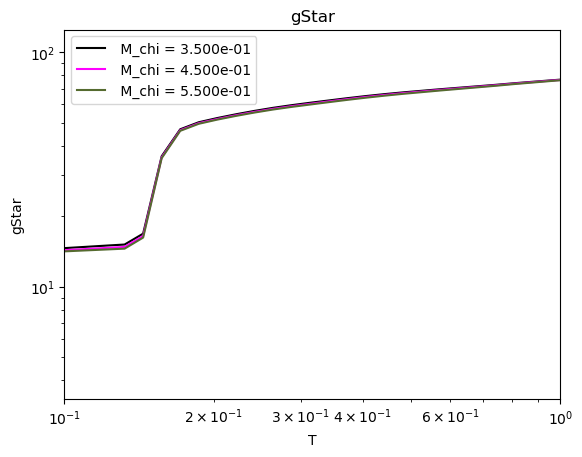

In [13]:
import matplotlib.pyplot as plt

m_test_vals = [0.35, 0.45, 0.55]
counter = 0
color_dict = ['black', 'fuchsia', 'darkolivegreen', 'goldenrod']
for m in m_test_vals:
    m_vals = np.ones(temps.shape)
    m_vals = m*m_vals
    gStarS_vals = gStarSTrue_np(temps, m_vals)
    gStar_vals = gStarTrue_np(temps, m_vals)
    plt.plot(temps, gStarS_vals, color = color_dict[counter], label = f" M_chi = {m:.3e}")
    #plt.plot(temps, gStar_vals, color = color_dict[counter], label = f"M_chi = {m:.3e}")
    counter += 1

plt.xscale('log'); 
plt.yscale('log')
plt.title(f'gStar')
plt.xlim(0.1,1)
plt.xlabel('T'); plt.ylabel('gStar')
plt.legend()
plt.show()

In [7]:
#just saving the previous work
#I don't think I run this cell anymore to make the information........

np.savetxt("gStarSTrue_answers.csv", gStarSTrue_answers, delimiter=",")
np.savetxt("gStarTrue_answers.csv", gStarTrue_answers, delimiter=",")

NameError: name 'gStarSTrue_answers' is not defined

In [6]:
#I calculate gStarS and gStar and then create a interperlator to calculate it easily for each temperature

gStarSTrue_answers_load = np.loadtxt("gStarSTrue_answers.csv", delimiter=",")
gStarTrue_answers_load = np.loadtxt("gStarTrue_answers.csv", delimiter=",")
interp_spline_gStarS = rect(masses, temps, gStarSTrue_answers_load)
interp_spline_gStar = rect(masses, temps, gStarTrue_answers_load)

temps2 = np.logspace(-6, 2, num = 500)
masses2 = np.logspace(-3, 1, num = 500)

Temps2, Masses2 = np.meshgrid(temps2, masses2)

gStarSTrue_answers2Int = interp_spline_gStarS(masses2, temps2)
gStarTrue_answers2Int = interp_spline_gStar(masses2, temps2)

temps3 = np.logspace(-3, -2.5, num = 250)
temps4 = np.logspace(-4, -1.5, num = 250)

y_gStarSTrue = gStarSTrue_np(temps4, 0.004)
y_gStarTrue = gStarTrue_np(temps3, 0.004)
y_gStarTrue = [x.item() for x in y_gStarTrue]
y_gStarSTrue = [x.item() for x in y_gStarSTrue]
#print(y_gStarTrue)

y_gStarS= interp_spline_gStarS(0.004, temps4)
y_gStar = interp_spline_gStar(0.004, temps3)
#print(y_gStar)

y_gStarSInt = [gStarSInt(t) for t in temps4]
y_gStarInt = [gStarInt(t) for t in temps3]


In [9]:
#doing some tests

#setting cosmological parameters and making some more functions
print(gStarSTrue(temps4[11], 0.004))
print(interp_spline_gStarS(0.004, temps4[11]))
print(interp_spline_gStarS(temps4[11], 0.004))

print("")
print(gStarTrue(temps3[11], 0.004))
print(interp_spline_gStar(0.004, temps3[11]))
print(interp_spline_gStar(temps3[11], 0.004))

5.285904375600023
[[5.28558377]]
[[15.53469427]]

10.272925829493573
[[10.2731762]]
[[15.51371327]]


In [7]:
#setting plank mass in GeV

m_planck = 1.22e19 #GeV

In [8]:
#calculating the energy density as a function of gStar and T and mchi
#answer comes from number density -> energy density -> to computing the high energy and low energy limits
#should the pi be squared????

def rho(T, mchi):
    gStar_value = interp_spline_gStar(mchi, T)
    answer = (math.pi*math.pi/30)*gStar_value[0][0]*(T**4)
    return answer

In [9]:
#making this a numpy function, so it can easily calculate the values from a mpy array

rho_np = np.frompyfunc(rho, 2, 1)

In [9]:
#calculating the hubble constant, this comes from utilizing the friedmann equations

def hubble(T, mchi):
    rho_value = rho(T, mchi)
    answer = math.sqrt((8*math.pi/(3*m_planck*m_planck))*rho_value)
    return answer

In [11]:
#making a numpy function again

hubble_np = np.frompyfunc(hubble, 2, 1)

In [10]:
#s is the entropy density, a conserved quantity, a function of mchi, T
#this equation is verified from my notes

def s_value(T, mchi):
    gStarS_value = interp_spline_gStarS(mchi, T)
    #print(gStarS_value[0][0])
    answer = (2*math.pi*math.pi/45)*gStarS_value[0][0]*(T**3)
    #jax_answer = jnp.array(answer)
    return answer

In [16]:
#doing some tests

answer_check = s_value(0.001, 0.01)
print((answer_check))

1.4512835224150695e-09


In [11]:
#CLAUDE WROTE THIS
#I need to verify this equation
#I use this function for my ODE

def ds_dT(T, mchi):
    """Derivative of entropy density s w.r.t. temperature T.

    s(T, mchi) = (2*pi*pi/45) * gStarS(mchi, T) * T^3

    By the product rule:
    ds/dT = (2*pi*pi/45) * [ dgStarS/dT * T^3 + gStarS * 3*T^2 ]

    RectBivariateSpline supports dy=1 to compute dgStarS/dT directly.
    """
    gStarS = interp_spline_gStarS(mchi, T)[0][0]
    dgStarS_dT = interp_spline_gStarS(mchi, T, dy=1)[0][0]
    return (2 * math.pi *math.pi/ 45) * (dgStarS_dT * T**3 + gStarS * 3 * T**2)

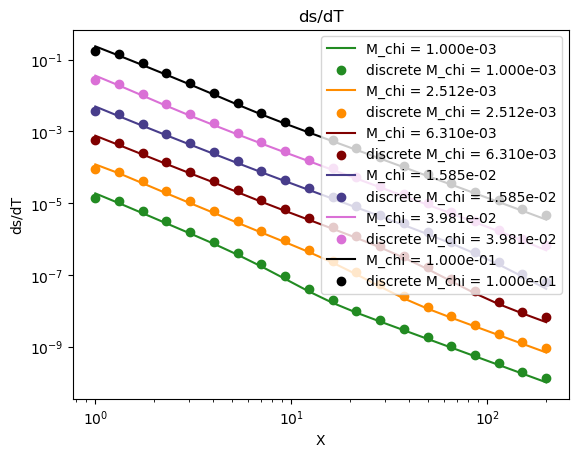

In [17]:
import matplotlib.pyplot as plt

m_values = np.logspace(-3, -1, 6)
x_values = np.logspace(0, 2.3, 20)


counter = 0
color_dict = ["forestgreen", "darkorange", "maroon", "darkslateblue", "orchid", "black"]
start_lin = time.time()
for m in m_values:
    
    dsdT = [ds_dT(m/x, m) for x in x_values]

    s = [s_value(m/x, m) for x in x_values]
    T = [m/x for x in x_values]

    deltas = np.gradient(s)
    deltaT = np.gradient(T)

    discretedsdT = np.divide(deltas, deltaT)
    
    plt.plot(x_values, dsdT, color = color_dict[counter], label = f"M_chi = {m:.3e}")
    plt.scatter(x_values, discretedsdT, color = color_dict[counter], label = f"discrete M_chi = {m:.3e}")
    counter += 1

plt.xscale('log'); 
plt.yscale('log')
plt.title(f"ds/dT")
plt.xlabel('X'); plt.ylabel('ds/dT')
plt.legend()
plt.show()

In [15]:
#making a numpy function

s_value_np = np.frompyfunc(s_value, 2, 1)

In [12]:
#this is calculating the y eq, which is ????
#I think this is the yield at matter/radiation equality (VERIFY)
#FIGURE THIS OUT

def y_eq(gchi, mchi, T):
    svalue = s_value(T, mchi)
    ratio = mchi/T
    bessel_value = kn(2, ratio)
    fraction = (gchi*mchi*mchi*T)/(2*math.pi*math.pi)
    answer = fraction*(bessel_value/svalue)
    return answer

In [17]:
#making a numpy function again

y_eq_np = np.frompyfunc(y_eq, 3, 1)

In [13]:
#now calculating the r ratio data
#first will start with importing the data

In [13]:
#inputting the R data, which was provided to me

rdataraw = np.loadtxt("/Users/afurataylor/Downloads/relic_abundance_calc-2/R_ratio.dat", skiprows = 52, usecols = (0,1,2,3), max_rows = 1393)

In [14]:
#I need to figure out what R data is exactly..... but separating the data into different columns

EDMRData = rdataraw[:,0]
RData = rdataraw[:,3]

In [15]:
#here, I create an interperlation function using the EDMR data as x, R data as y

def rInt(x):
    r_Int = scipy.interpolate.interp1d(EDMRData, RData,bounds_error=False,fill_value="extrapolate")
    return r_Int(x)

In [16]:
#IMPORTANT TO NOTE, the given x is already the sqrt value, then I use the interperlation function created in the cell above for a specific range

def rFunc(x):
    #sqrt = math.sqrt(x)
    sqrt = x
    if sqrt < 4 and sqrt > 0.3:
        answer1 = rInt(sqrt)
        answer = answer1
    else:
        answer = 0
    return answer

Text(0, 0.5, 'R Function Output')

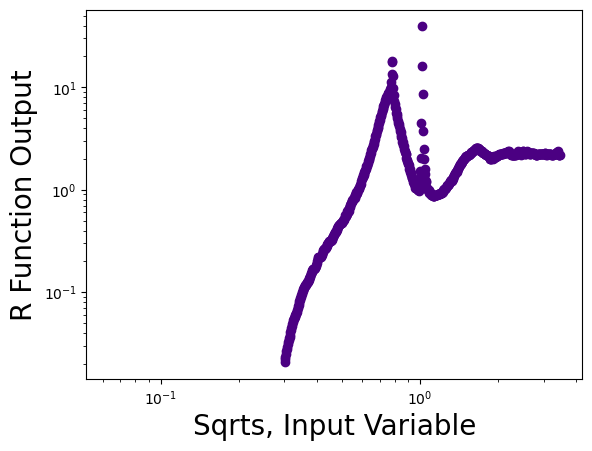

In [25]:
#making a graph to double check the previous functions were right (they were)

rFunc_np = np.frompyfunc(rFunc, 1, 1)
import matplotlib.pyplot as plt
ax = plt.gca()
x_val_gammaA = np.logspace(-1, math.log10(300), 1000)
sqrts = 0.2*np.sqrt(x_val_gammaA)
#print(sqrts)
#y_val_gammaA = gammaA_np((1/10), sqrts, 0.1, 0.3)
y_val_rFunc = rFunc_np(sqrts)
plt.scatter(sqrts, y_val_rFunc, c='indigo')
plt.xscale('log')
plt.yscale('log')
ax.set_xlabel("Sqrts, Input Variable", fontsize = 20)
ax.set_ylabel("R Function Output", fontsize = 20)

Text(0, 0.5, 'R Function Output')

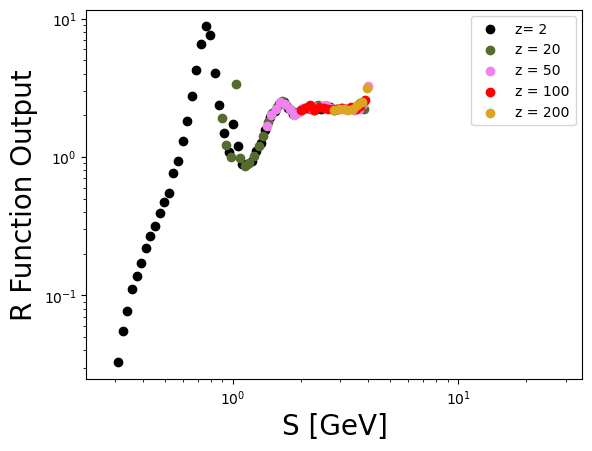

In [33]:
rFunc_np = np.frompyfunc(rFunc, 1, 1)
import matplotlib.pyplot as plt
ax = plt.gca()
mx_values = np.logspace(0, -1, 50)
x_test_val2 = 2
x_test_val20 = 20
x_test_val200 = 200
x_test_val50 = 50
x_test_val100 = 100

call_values2 = 2*mx_values*math.sqrt(x_test_val2)
call_values20 = 2*mx_values*math.sqrt(x_test_val20)
call_values200 = 2*mx_values*math.sqrt(x_test_val200)
call_values50 = 2*mx_values*math.sqrt(x_test_val50)
call_values100 = 2*mx_values*math.sqrt(x_test_val100)


rFunc_vals2 = rFunc_np(call_values2)
rFunc_vals20 = rFunc_np(call_values20)
rFunc_vals200 = rFunc_np(call_values200)
rFunc_vals100 = rFunc_np(call_values100)
rFunc_vals50 = rFunc_np(call_values50)

plt.scatter(call_values2, rFunc_vals2, label = 'z= 2', color = 'black')
plt.scatter(call_values20, rFunc_vals20, label = 'z = 20', color = 'darkolivegreen')
plt.scatter(call_values50, rFunc_vals50, label = 'z = 50', color = 'violet')
plt.scatter(call_values100, rFunc_vals100, label = 'z = 100', color = 'red' )
plt.scatter(call_values200, rFunc_vals200, label =  'z = 200' , color = 'goldenrod')
#(f"New Sigma Analytic Function x = {x_test[57]:.3e}")


plt.xscale('log')
plt.yscale('log')
plt.legend()
ax.set_xlabel("S [GeV]", fontsize = 20)
ax.set_ylabel("R Function Output", fontsize = 20)

In [22]:
#this was getting y values from a numpy function, which I don't think I made in this notebook version

rFunc_values = rFunc_np(EDMRData)

NameError: name 'rFunc_np' is not defined

In [17]:
#this must calculate something regarding the dark photon mediator, but what ?????
#get a reference!

#perhaps can call rFunc in the beginning of the function, but I think that it won't help here, maybe it will 
#be better if I calculate it, then pass it as a variable? we'll see in the rewrite.......
def gammaA(eps, sqrts, mchi, mA):
    result = 0 
    '''If[2 mchi < sqrts, (4 \[Pi]*0.5)/(48 \[Pi])
       sqrts (1 - 4 mchi^2/sqrts^2)^(3/2), 0]'''
    
    if 2*mchi < sqrts:
        #result += ((4*math.pi*0.5)/(48*math.pi)) * sqrts * math.pow((1 - 4*(mchi/sqrts)*(mchi/sqrts)), 1.5) 
        result += ((4*math.pi*0.5)/(48*math.pi)) * sqrts * math.pow((1 - 4*((mchi*mchi)/(sqrts*sqrts))), 1.5)
    if 2*mmu < sqrts:
        #this might be a problem area...... 
        result += math.pow((eps*math.sqrt((4*math.pi)/137)), 2)*math.sqrt(1 - ((4*mmu*mmu)/(sqrts*sqrts)))*(sqrts/(12*math.pi))*(1 + ((2*mmu*mmu)/(sqrts*sqrts)))*(1+rFunc(sqrts))

    if 2*me < sqrts:
        result += math.pow((eps*math.sqrt((4*math.pi)/137)), 2)*(sqrts/(12*math.pi))*math.sqrt(1- ((4*me*me)/(sqrts*sqrts)))*(1 + ((2*me*me)/(sqrts*sqrts)))
    #result += math.pow((eps*math.sqrt((4*math.pi)/137)), 2)*(sqrts/(12*math.pi))*math.sqrt(1- ((4*me*me)/(sqrts*sqrts)))*(1 + ((2*me*me)/(sqrts*sqrts)))
    return result

In [36]:
#making a numpy function

gammaA_np = np.frompyfunc(gammaA, 4, 1)

In [18]:
#this was to try parallelizing the integration, was not helpful
#MUST RUN
worker_num = 1

In [18]:
#need to delete the unnecesary parts, I am also wondering if there are some issues with the 
#different cases of x, that I worked with earlier
def sigmave(x, T, eps, mchi, mA):
    call_value = 2*mchi*math.sqrt(x)
    ratio1 = (2*mchi*math.sqrt(x))/T

    
    
    if x - 1 < 0:
        print("What the HELLY") 
        
    num1 = 4*mchi*mchi*(math.sqrt(4*mchi*mchi*(x-1))*math.sqrt(4*mchi*mchi*x - 4*me*me)*(2*me*me + 4*mchi*mchi*x))
    num2 = (4*mchi*mchi*(x-1))*2*mchi*math.sqrt(x)*kn(1, ratio1)
    num = num1*num2
    
    denom = (12*math.pi*(4*mchi*mchi*x)*(math.pow((mA*mA - 4*mchi*mchi*x),2) + mA*mA*math.pow(gammaA(eps, call_value, mchi, mA), 2)))
    
    answer = num/denom

    #print("num1=", num1)
    #print("num2=", num2)
    #print("num1*num2=", num)
    #print("______")
    #print('denom=', denom)
    #print('answer=', answer)


    return answer

In [19]:
def sigmavAnalytice(T, eps, mchi, mA, absep, repep):
    #from __main__ import sigmave
    #does not need above line with fork being set as start method!
    ratio = mchi/T
    bessel_value = kn(2, ratio)
    break_point = (mA*mA)/(4*mchi*mchi)
    
    constant_num = ((4*math.pi)/137)*math.pow((eps*math.sqrt(4*math.pi*0.5)), 2)
    constant_denom = 8*math.pow(mchi, 4)*T*math.pow(bessel_value,2)
    constant = constant_num/constant_denom
    
    #print(constant)
    
    break_point_minus = break_point - 1e-17*break_point
    break_point_plus = break_point + 1e-17*break_point
    
    if break_point <1:
        
        integrand = scipy.integrate.quad_vec(sigmave, 1, np.inf, args = (T, eps, mchi, mA), epsabs=absep, epsrel=repep, limit=200, workers = worker_num)
        answer = constant*integrand[0]
        #print("integrand=", integrand[0])
    if break_point > 1:
        if break_point_minus < 1: 
            print("HOUSTON WE HAVE A PROBLEM")
        
        integrand_lower = scipy.integrate.quad_vec(sigmave, 1, break_point_minus, args = (T, eps, mchi, mA), epsabs=absep, epsrel=repep, limit=200, workers = worker_num)
        
        integrand_plus = scipy.integrate.quad_vec(sigmave, break_point_plus, np.inf, args = (T, eps, mchi, mA), epsabs=absep, epsrel=repep, limit=200, workers = worker_num)
        answer = constant * (integrand_lower[0] + integrand_plus[0])
        #print("integrand lower=", integrand_lower[0],"integrand plus=", print(integrand_plus[0]))
        
    return answer

[3.16227766e-01 1.11109830e-08]


Text(0, 0.5, 'Sigmavmu')

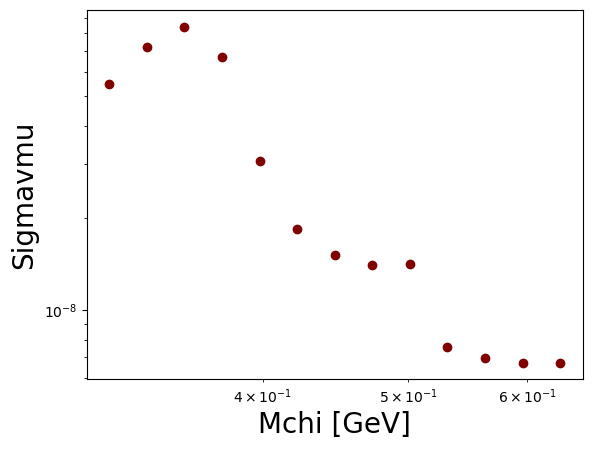

In [63]:
mathematica_sigmave = np.loadtxt("/Users/afurataylor/Downloads/relic_abundance_calc/sigmave_vs_mchi.csv", dtype = str)
mathematica_sigmavmu = np.loadtxt("/Users/afurataylor/Downloads/relic_abundance_calc/sigmavmu_vs_mchi.csv", dtype = str)
#float_mathematica_sigmave= mathematica_sigmave.astype(float)
float_mathematica_sigmave = np.array([list(map(float, s.split(','))) for s in mathematica_sigmave])
float_mathematica_sigmavmu = np.array([list(map(float, s.split(','))) for s in mathematica_sigmavmu])
print(float_mathematica_sigmave[0])
residual_list_sigmave = []
residual_list_sigmavmu = []
python_sigmavmu_list = []
mchi_list = []
mchi_list_mu = []
for row in float_mathematica_sigmave:
    #print(row)
    mchi = row[0]
    T = mchi/20
    eps = 1.5e-3
    mA = 3*mchi
    python_sigmave = sigmavAnalytice(T, eps, mchi, mA)
    mathematica_sigmave = row[1]
    residual = (mathematica_sigmave - python_sigmave)/mathematica_sigmave
    residual_list_sigmave.append(residual)
    mchi_list.append(mchi)

for row in float_mathematica_sigmavmu:
    #print(row)
    mchi = row[0]
    T = mchi/20
    eps = 1.5e-3
    mA = 3*mchi
    python_sigmavmu = sigmaAnalyticmu(T, eps, mchi, mA)
    python_sigmavmu_list.append(python_sigmavmu)
    mathematica_sigmavmu = row[1]
    residual = (mathematica_sigmavmu - python_sigmavmu)/mathematica_sigmavmu
    residual_list_sigmavmu.append(residual)
    mchi_list_mu.append(mchi)

import matplotlib.pyplot as plt
ax = plt.gca()
plt.scatter(mchi_list, python_sigmavmu_list, color = "maroon")
#plt.scatter(mchi_list, residual_list_sigmave, color = "maroon", label = "sigmave")
#plt.scatter(mchi_list_mu, residual_list_sigmavmu, color = "darkolivegreen", label = "sigmavmu")
plt.xscale('log')
plt.yscale('log')
#ax.legend()
ax.set_xlabel("Mchi [GeV]", fontsize = 20)
ax.set_ylabel("Sigmavmu", fontsize = 20)

In [20]:
def sigmavmu(x, T, eps, mchi, mA):
    call_value = 2*mchi*math.sqrt(x)
    ratio1 = (2*mchi*math.sqrt(x))/T

    num1 = 4*mchi*mchi*(math.sqrt(4*mchi*mchi*(x-1))*math.sqrt(4*mchi*mchi*x - 4*mmu*mmu)*(2*mmu*mmu + 4*mchi*mchi*x))
    num2 = (4*mchi*mchi*(x-1))*2*mchi*math.sqrt(x)*kn(1, ratio1)*(1 + rFunc(call_value))
    num = num1*num2
    
    denom = (12*math.pi*(4*mchi*mchi*x)*(math.pow((mA*mA - 4*mchi*mchi*x),2) + mA*mA*math.pow(gammaA(eps, call_value, mchi, mA), 2)))
    
    answer = num/denom

    
    #print("num1=", num1)
    #print("num2=", num2)
    #print("num1*num2=", num)
    #print("______")
    #print('denom=', denom)
    #print('answer=', answer)


    return answer 

In [21]:
#need to set the break point plus/minus relative to the break point itself
#maybe break point/ 1000000000 ? something like this?
def sigmaAnalyticmu(T, eps, mchi, mA, absep, repep):
    #from __main__ import sigmavmu
    answer = 0
    
    ratio = mchi/T
    bessel_value = kn(2, ratio)

    constant_num = ((4*math.pi)/137)*math.pow((eps*math.sqrt(4*math.pi*0.5)), 2)
    constant_denom = 8*math.pow(mchi, 4)*T*math.pow(bessel_value,2)
    constant = constant_num/constant_denom

    max_test = (mmu*mmu)/(mchi*mchi)
    max_value = max(max_test, 1)
    
    break_point = (mA*mA)/(4*mchi*mchi)
    
    if mchi > mmu/5:
        if ((mmu*mmu)/(mchi*mchi)) < ((mA*mA)/(4*mchi*mchi)):
            if break_point > max_value:
                break_point_minus = break_point - 1e-17*break_point
                break_point_plus = break_point + 1e-17*break_point
            
                integrand_lower = scipy.integrate.quad_vec(sigmavmu, max_value, break_point_minus, args = (T, eps, mchi, mA) , epsabs=absep, epsrel=repep, limit=200, workers = worker_num)
                integrand_plus = scipy.integrate.quad_vec(sigmavmu, break_point_plus, np.inf, args = (T, eps, mchi, mA),epsabs=absep, epsrel=repep, limit=200, workers = worker_num)
                result = (integrand_lower[0] + integrand_plus[0])
            else:
                integrand = scipy.integrate.quad_vec(sigmavmu, max_value, np.inf, args = (T, eps, mchi, mA), epsabs=absep, epsrel=repep, limit=200, workers = worker_num)
                
                result = integrand[0]
        else:
            #this might need to be zero...........
            
            integrand = scipy.integrate.quad_vec(sigmavmu, max_value, np.inf, args = (T, eps, mchi, mA), epsabs=absep, epsrel=repep, limit=200, workers = worker_num)
            result = integrand[0]
        answer = constant*result
        
    return answer 

In [22]:
def sigmaAnalytic(x, eps, mchi, absep, repep):
    mA = 3*mchi
    T = mchi/x
    answer = sigmavAnalytice(T, eps, mchi, mA, absep, repep) + sigmaAnalyticmu(T, eps, mchi, mA, absep, repep)
    return answer

In [25]:
#mathematica_sigmav = np.loadtxt("/Users/afurataylor/Download/relic_abundance_calc-2/sigmAnalyticAfura.csv", dtype = str)
#float_mathematica_sigmav = np.array([list(map(float, s.split(','))) for s in mathematica_sigmav])

In [37]:
worker_num = 1
print(sigmaAnalytic(2, 10**-3, 0.5, 1e-27, 1e-5))

2.575229341945144e-06


In [92]:
import pandas as pd
sc_mass_list = np.load("/Users/afurataylor/Downloads/masseslist.npy")
sc_python_list = np.load("/Users/afurataylor/Downloads/pythonsigma.npy")
sc_math_list = np.load("/Users/afurataylor/Downloads/mathematicasigma.npy")
sc_residual_list = np.load("/Users/afurataylor/Downloads/residualsigma.npy")
sc_pythontrue_list = []
sc_trueresidual_list = []
sc_python_test = []
sc_residual_test = []
mathematica_sigmas = pd.read_csv("/Users/afurataylor/script/log10sigmavScalarTab.csv")




sigma_subsection = mathematica_sigmas.loc[mathematica_sigmas['x1'] > -0.53]
sigma_subsection = sigma_subsection.loc[sigma_subsection['x1'] < -0.2]
sigma_subsection = sigma_subsection.loc[sigma_subsection['x2'] < 1.5]
sigma_subsection = sigma_subsection.loc[sigma_subsection['x2'] > 1.2]
sigma_subsection = sigma_subsection.loc[sigma_subsection['x3'] < -2.8]
sigma_subsection = sigma_subsection.loc[sigma_subsection['x3'] > -3.3]
sigma_subsection_np = sigma_subsection.to_numpy()

for row in sigma_subsection_np:
    sigma_math = 10**row[3]
    sigma_py_log10 = sigmaAnalytic(10**row[1], 10**row[2], 10**row[0], 1e-27, 1e-5)
    sigma_py_interp = interp_log10_new_x3([10**row[1], 10**row[2], 10**row[0]])
    sc_python_test.append(10**sigma_py_interp)
    #sigma_py = 10**sigma_py_log10
    residual = abs(sigma_math - sigma_py_log10)/sigma_math
    sc_pythontrue_list.append(sigma_py_log10)
    sc_trueresidual_list.append(residual)
    residual_test = abs(sigma_math - 10**(sigma_py_interp))/sigma_math
    sc_residual_test.append(residual_test)

Text(0, 0.5, 'SigmaV Output')

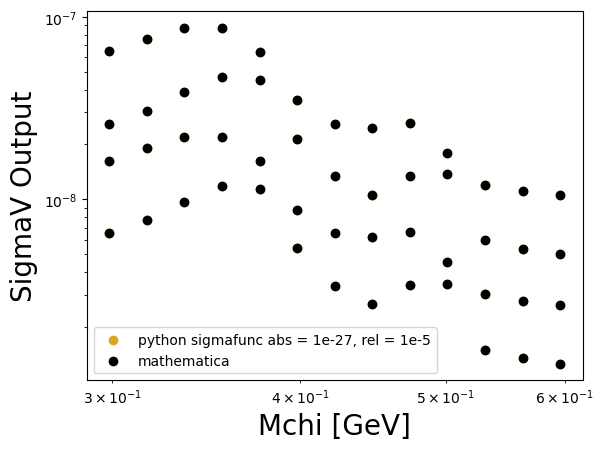

In [95]:
import matplotlib.pyplot as plt

ax = plt.gca()



#plt.scatter(sc_mass_list,sc_python_test, label = 'python interp abs = 1e-27, rel = 1e-5', color = 'fuchsia')
plt.scatter(sc_mass_list, sc_pythontrue_list, label = 'python sigmafunc abs = 1e-27, rel = 1e-5', color = 'goldenrod')
plt.scatter(sc_mass_list, sc_math_list, label = 'mathematica', color = 'black')
#plt.scatter(sc_mass_list, sc_python_test,  label = 'python interp', color = 'fuchsia')
#plt.scatter(sc_mass_list, sc_residual_test, label = 'residuals interp', color = 'navy')
#plt.scatter(sc_mass_list, sc_trueresidual_list, label = 'residuals sigmafunc', color = 'fuchsia')
plt.xscale('log')
plt.yscale('log')
plt.legend()
ax.set_xlabel("Mchi [GeV]", fontsize = 20)
ax.set_ylabel("SigmaV Output", fontsize = 20)
#ax.set_ylabel("SigmaV Residuals", fontsize = 20)

In [100]:
x_ = np.linspace(100, 200, 100)
eps_ = np.linspace(1e-6, 1e-2, 100)
mchi_ = np.linspace(1e-3, 1e-1, 100)

In [107]:
mchi_.shape

(5, 5, 5)

In [110]:
x_, eps_, mchi_ = np.meshgrid(x_test, eps_test, mchi_test, indexing='ij')
x_ = x_.flatten()
eps_ = eps_.flatten()
mchi_ = mchi_.flatten()

In [115]:
for x in x_test:
    timer_start = time.time()
    eps_, mchi_ = np.meshgrid(eps_test, mchi_test, indexing='ij')
    sigmavAnalytic_np(x, eps_, mchi_)
    print(time.time() - timer_start, x)

7.264507055282593 0.5011872336272722
3.4444050788879395 2.51188643150958
0.14237022399902344 12.589254117941667
0.1419084072113037 63.095734448019265
0.14168691635131836 316.22776601683796


In [79]:
sigmavAnalytic_np = np.frompyfunc(sigmaAnalytic, 5, 1)
sigmavAnalytictest_np = np.frompyfunc(sigmaAnalytictest, 5, 1)

In [35]:
mchi_sanity_check = 1e-3
T_sanity_check = mchi_sanity_check/10
mA_sanity_check = 3*mchi_sanity_check
eps_sanity_check = 1e-2

print(sigmaAnalytic(T_sanity_check, eps_sanity_check, mchi_sanity_check))
print(sigmavAnalytice(T_sanity_check, eps_sanity_check, mchi_sanity_check, mA_sanity_check))

0.34560101241351354
0.34560101241351354


In [35]:
input_values = np.loadtxt("/Users/afurataylor/Downloads/relic_abundance_calc-2/inputvalues.csv", dtype = np.str_)
out_sigmav_values = np.loadtxt("/Users/afurataylor/Downloads/relic_abundance_calc-2/outputvalues.csv", dtype = np.str_)
table_values = []


for i in input_values:
    i = i.split(",")
    table_values.append(i)



    



In [23]:
mathematica_sigma = np.loadtxt("/Users/afurataylor/Downloads/relic_abundance_calc-2/log10sigmavScalarTab.dat", dtype=str, delimiter = ",")
print(mathematica_sigma)

log10sigmavTab


        x1   x2   x3  log10sigmav
0     -3.0 -1.0 -5.6    -9.499971
1     -3.0 -1.0 -5.3    -8.899971
2     -3.0 -1.0 -5.0    -8.299971
3     -3.0 -1.0 -4.7    -7.699971
4     -3.0 -1.0 -4.4    -7.099971
...    ...  ...  ...          ...
23647  0.2  2.4 -1.7    -7.701784
23648  0.2  2.4 -1.4    -7.101784
23649  0.2  2.4 -1.1    -6.501784
23650  0.2  2.4 -0.8    -5.901784
23651  0.2  2.4 -0.5    -5.301785

[23652 rows x 4 columns]


In [63]:
sigmav_values_mine = []
results = []
log10mx = []
log10x = []
log10eps = []
for i in table_values:
    log10mx.append(i[0])
    log10x.append(i[1])
    log10eps.append(i[2])

mx = []
x = []
eps = []

for i in range(len(log10mx)):
    mx.append(math.pow(10, float(log10mx[i])))
    x.append(math.pow(10, float(log10x[i])))
    eps.append(math.pow(10, float(log10eps[i])))

for i in range(len(mx)):
    mx_value = mx[i]
    x_value = x[i]
    eps_value = eps[i]
    T_value = mx[i]/x[i]
    mA_value = 3*mx[i]
    sigma_value_interim = sigmaAnalytic(T_value, eps_value, mx_value, mA_value)
    sigmav_values_mine.append(sigma_value_interim)
    results.append([T_value, eps_value, mx_value, mA_value, sigma_value_interim])


    

In [75]:
y = []

mathematica_result = [0.000232297, 0.00141904, 0.0000391598, 0.0000391598e-14, 4.21251e-6, 3.02359e-11, 7.68927e-8, 5.25541e-11,0.00410293, 0.00942156, 3.17169e-7,8.62073e-10, 0.0000142793, 1.7004e-6,2.09669e-7]
for i in range(len(results)):
    myresult = results[i][4]
    mathematica_result_interim = mathematica_result[i]
    y.append(myresult)
x = mathematica_result

In [127]:
print(math.pow(10, 8.77740970922995e-05))
from tqdm import tqdm

1.0002021277525777


In [24]:
worker_num = 1
start = time.time() 
#mchi_test = np.logspace(-0.53, -0.2, num = 20) 
#mchi_test = np.logspace(-3.1, 0.06, num = 100) 
mchi_p1 = np.logspace(-3.1, -0.55, num = 81) 
mchi_p2 = np.logspace(-0.54, -0.3, num = 30)
mchi_p3 = np.logspace(-0.29, 0.06, num = 11) 
#mchi_test = np.concatenate((mchi_p1, mchi_p2, mchi_p3), axis = 0) 
mchi_test = mchi_p2 
mchi_test = np.logspace(-3.1, 0.06, num = 100) 
#print(mchi_test.shape) 
x_test = np.logspace(0, 2.5, num = 100) 
eps_test = np.logspace(-5.9, -0.4, num = 100) 
#T_test = mchi_test/x_test mA_test = 3*mchi_test 
result = sigmaAnalytic(2, eps_test[4], mchi_test[0], 1e-27, 1e-5) 
#result = sigmavAnalytic_np(x_test, eps_test, mchi_test) print(time.time() - start) 
#print(result) #print(mchi_test[-1]) #print(mchi_test[0]/x_test) #print(mchi_test[-1]/x_test) 
#print(mchi_test)

# worker_num = 1
start = time.time()
#mchi_test = np.logspace(-0.53, -0.2, num = 20)
#mchi_test = np.logspace(-3.1, 0.06, num = 100)
mchi_p1 = np.logspace(-3.1, -0.55, num = 81)
mchi_p2 = np.logspace(-0.54, -0.3, num = 30)
mchi_p3 = np.logspace(-0.29, 0.06, num = 11)
#mchi_test = np.concatenate((mchi_p1, mchi_p2, mchi_p3), axis = 0)
mchi_test = mchi_p2
mchi_test = np.logspace(-3.1, 0.06, num = 100)
print(mchi_test.shape)
x_test = np.logspace(0, 2.5, num = 100)
eps_test = np.logspace(-5.9, -0.4, num = 100)
#T_test = mchi_test/x_test
mA_test = 3*mchi_test
result = sigmaAnalytic(2, eps_test[4], mchi_test[0], 1e-27, 1e-5)
#result = sigmavAnalytic_np(x_test, eps_test, mchi_test)
print(time.time() - start)
#print(result)
#print(mchi_test[-1])
#print(mchi_test[0]/x_test)
#print(mchi_test[-1]/x_test)
#print(mchi_test)

In [42]:
start = time.time()
from multiprocessing.pool import Pool

# function = sigmaAnalytic(T, eps, mchi, mA)

#need to make items list 
#first need to use numpy concatenate

input_vals = np.concatenate((T_test, eps_test, mchi_test), axis = 0)
#print(list(zip(T_test, eps_test, mchi_test, mA_test))) 
input_vals_fr = zip(T_test, eps_test, mchi_test)
start_2 = time.time()
if __name__ == "__main__":
    with Pool() as pool:
        result = pool.starmap(sigmaAnalytic, input_vals_fr, chunksize = 10)
    print(time.time()-start_2)
#Temps, Eps, Mchis, MAs = np.meshgrid(T_test, eps_test, mchi_test, mA_test, indexing = "ij",  sparse = True)

2.0583128929138184


In [27]:
from scipy.interpolate import RegularGridInterpolator
from multiprocessing.pool import Pool
#Temps, Eps, Mchis = np.meshgrid(T_test, eps_test, mchi_test, indexing = "ij",  sparse = True)
#print(Temps)
#input_vals_mesh = zip(Temps.ravel(), Eps.ravel(), Mchis.ravel())
#input_vals_test = zip(Temps, Eps, Mchis)
start_2 = time.time()
values_list = []
x_list = []
eps_list = []
mchi_list = []
final_array_x = np.ones((len(x_test), len(eps_test), len(mchi_test)))
#print(time.time() - start_2)
start_3 = time.time()
for k in range(len(mchi_test)):
    for j in range(len(eps_test)):
        for i in range(len(x_test)):
            values_list.append((x_test[i], eps_test[j], mchi_test[k], 1e-27, 1e-5))


start_testtime = time.time()


'''
for i in T_test:
    for j in eps_test:
        for k in mchi_test:
            values_list.append((i,j,k))'''

#print(len(values_list))
#print(values_list[0])
counter = 0
start_4 = time.time()

time_pool = time.time()   
if __name__ == "__main__":
    with Pool() as pool:
        result_data = pool.starmap(sigmaAnalytic, values_list, chunksize = 10)

#print(result_data == result_data_np)
print("time of pool", time.time() - start_4)

#print(time.time() - start_4)
#start_5 = time.time()

for k in range(len(mchi_test)):
    for j in range(len(eps_test)):
        for i in range(len(x_test)):
            final_array_x[int(i), int(j), int(k)] = result_data[counter]
            counter += 1
#print(time.time() - start_2)
#NEXT STEP REMOVE MA AS INPUT PARAMETER AND SET MA = 3*MCHI


KeyboardInterrupt: 

In [46]:
#np.save("log10sigmavScalarTabx.npy", final_array_x)

In [25]:
worker_num = 1

In [55]:
log10_sigmav_x = np.log10(final_array_x)
interp_log10_x3 = RegularGridInterpolator((x_test, eps_test, mchi_test), log10_sigmav_x, method = "cubic", bounds_error=False, fill_value=None)

NameError: name 'result_data' is not defined

In [27]:
value = 22
eps_num = 23
eps_num = 44
m_num = 55
x_test_splice = x_test[::3]
for x_num in range(len(x_test_splice)):
    sigma_run = math.log10(sigmaAnalytic(x_test[x_num], eps_test[eps_num], mchi_test[m_num], 1e-27, 1e-5))
    #sigma_interp = interp_log10_x3([x_test[x_num], eps_test[eps_num], mchi_test[m_num]])
    sigma_grid = final_array_x_new[x_num, eps_num, m_num]

        #print(abs(sigma_run - sigma_grid))

NameError: name 'final_array_x_new' is not defined

In [60]:
print(math.log10(sigmaAnalytic(x_test[1], eps_test[0], mchi_test[4], 1e-27, 1e-5)))
print(interp_log10_x3([x_test[1], eps_test[0], mchi_test[4]]))
print(np.log10(final_array_x[1, 0, 4]))

-9.706265027529033
[-9.7062616]
-9.706265027529033


In [25]:
from scipy.interpolate import RegularGridInterpolator
#final_array = np.load("log10sigmavScalarTab.npy")
final_array_x = np.load("log10sigmavScalarTabx.npy")
final_array_x_new = np.load('/Users/afurataylor/Downloads/log10x.npy')
#log10_sigmav = np.log10(final_array)
log10_sigmav_x = np.log10(final_array_x)
#log10_sigmavnew_x = np.log10(final_array_x_new)
#interp = RegularGridInterpolator((T_test, eps_test, mchi_test), final_array, bounds_error=False, fill_value=None)
#interp_log10 = RegularGridInterpolator((T_test, eps_test, mchi_test), log10_sigmav, bounds_error=False, fill_value=None)
interp_log10_x3 = RegularGridInterpolator((x_test, eps_test, mchi_test), log10_sigmav_x, method = "cubic", bounds_error=False, fill_value=None)
#interp_log10_x = RegularGridInterpolator((x_test, eps_test, mchi_test), log10_sigmav_x, bounds_error=False, fill_value=None)
interp_log10_new_x3 = RegularGridInterpolator((x_test, eps_test, mchi_test), final_array_x_new, method = 'cubic', bounds_error=False, fill_value=None)
#print(interp_log10_x3([x_test[11], eps_test[0], mchi_test[99]]))
#print(math.log10(sigmaAnalytic(x_test[11], eps_test[0], mchi_test[99], 1e-23, 1e-2)))
#print(interp((Temps[0], Eps[0], Mchis[0])))
#print(T_test[11])
#print(eps_test[24])
#print(mchi_test[0])

In [47]:
print(interp_log10_new_x3([x_test[x_num], eps_test[eps_num], mchi_test[99]]))
print(math.log10(sigmaAnalytic(x_test[x_num], eps_test[eps_num], mchi_test[99], 1e-22, 1e-1)))
print(final_array_x_new[x_num, eps_num, 99])
eps_num = 27
x_num = 15
mchi_splice = mchi_test[::3]
for m_num in range(len(mchi_splice)):
    sigma_run = math.log10(sigmaAnalytic(x_test[x_num], eps_test[eps_num], mchi_splice[m_num], 1e-27, 1e-5))
    sigma_interp = interp_log10_new_x3([x_test[x_num], eps_test[eps_num], mchi_splice[m_num]])
    sigma_grid = log10_sigmav_x[x_num, eps_num, m_num*3]

                                       
    

[-10.46997517]
-10.470001906626859
-10.470001906285558


In [112]:
mchi_test_clip = mchi_test[69:76]
print(mchi_test_clip)

[0.30115347 0.32821741 0.35771352 0.38986037 0.42489618 0.46308058
 0.50469651]


print(x_test[52])
print(eps_test[50])
print(mchi_test[50])

In [131]:
m_list_ie = np.logspace(-1, 0, 25)
eps_ie = 1e-4
x_ie = 100

sigma_func_ie = []
sigma_interp_ie = []
residual_ie = []
sigma_run_ie = []
dif_ie = []
for i in range(len(mchi_test_clip)):
    sigma_func_run = sigmaAnalytic(x_test[88], eps_test[33], mchi_test[i+69], 1e-27, 1e-5)
    sigma_func = final_array_x_new[88, 33, (i+69)]
    dif = abs(sigma_func_run - 10**(sigma_func))
    dif_ie.append(dif)
    sigma_func = 10**sigma_func
    sigma_interp = interp_log10_x3([x_test[52], eps_test[46], mchi_test[i+69]])
    residual = abs(sigma_func - 10**(sigma_interp))/sigma_func

    sigma_run_ie.append(sigma_func_run)
    sigma_func_ie.append(sigma_func)
    sigma_interp_ie.append(10**(sigma_interp))
    residual_ie.append(residual)

Text(0, 0.5, 'SigmaV Output')

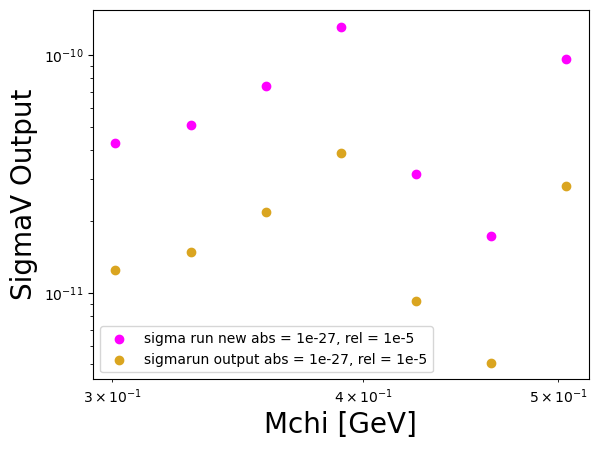

In [133]:
import matplotlib.pyplot as plt

ax = plt.gca()


plt.scatter(mchi_test_clip,sigma_run_ie, label = 'sigma run new abs = 1e-27, rel = 1e-5', color = 'fuchsia')
plt.scatter(mchi_test_clip,sigma_func_ie, label = 'sigmarun output abs = 1e-27, rel = 1e-5', color = 'goldenrod')
#plt.scatter(mchi_test_clip, sigma_interp_ie, label = 'sigma interp abs = 1e-27, rel = 1e-5', color = 'black')
#plt.scatter(mchi_test_clip, dif_ie,  label = 'residuals', color = 'navy')

plt.xscale('log')
plt.yscale('log')
plt.legend()
ax.set_xlabel("Mchi [GeV]", fontsize = 20)
ax.set_ylabel("SigmaV Output", fontsize = 20)
#ax.set_ylabel("SigmaV Residuals", fontsize = 20)

In [64]:
log10_sigmav_x = np.log10(final_array_x)
interp_log10_x3_test = RegularGridInterpolator((x_test, eps_test, mchi_test), log10_sigmav_x, method = "cubic", bounds_error=False, fill_value=None)

In [62]:
x_random = np.random.choice(x_test, 10)
eps_random = np.random.choice(eps_test, 10)
mchi_random = np.random.choice(mchi_test, 10)
for m in mchi_random:
    for e in eps_random:
        for x in x_random:
            
            dif = sigmaAnalytic(x, e, m, 1e-23, 1e-2) - (10**interp_log10_x3((x, e, m)))
            residual = dif/sigmaAnalytic(x, e, m, 1e-23, 1e-2)
            if abs(residual) >= 1e-3:
                print("values", x, m, e)
                print("residual", abs(residual))

In [46]:
import pandas as pd
mathematica_sigmas = pd.read_csv("/Users/afurataylor/Downloads/log10sigmavScalarTab.csv")
print(mathematica_sigmas)

        x1   x2   x3  log10sigmav
0     -3.0 -1.0 -5.6    -9.499971
1     -3.0 -1.0 -5.3    -8.899971
2     -3.0 -1.0 -5.0    -8.299971
3     -3.0 -1.0 -4.7    -7.699971
4     -3.0 -1.0 -4.4    -7.099971
...    ...  ...  ...          ...
23647  0.2  2.4 -1.7    -7.701784
23648  0.2  2.4 -1.4    -7.101784
23649  0.2  2.4 -1.1    -6.501784
23650  0.2  2.4 -0.8    -5.901784
23651  0.2  2.4 -0.5    -5.301785

[23652 rows x 4 columns]


In [47]:
sigma_subsection = mathematica_sigmas.loc[mathematica_sigmas['x1'] > -0.53]
sigma_subsection = sigma_subsection.loc[sigma_subsection['x1'] < -0.2]
sigma_subsection = sigma_subsection.loc[sigma_subsection['x2']  < 1.5]
sigma_subsection = sigma_subsection.loc[sigma_subsection['x2'] > 1.2]
sigma_subsection = sigma_subsection.loc[sigma_subsection['x3'] < -2.8]
sigma_subsection = sigma_subsection.loc[sigma_subsection['x3'] > -3.3]
#print(sigma_subsection)

In [47]:
sigma_subsection_np = sigma_subsection.to_numpy()
residuals_list = []
sigma_py_list = []
m_list = []
sigma_math_list = []
start = time.time()
for row in sigma_subsection_np:
    m_list.append(10**row[0])
    sigma_math = 10**row[3]
    sigma_math_list.append(sigma_math)
    #sigma_py_log10 = interp_log10_x3_test([10**row[1], 10**row[2], 10**row[0]])
    sigma_py_log10 = sigmaAnalytic(10**row[1], 10**row[2], 10**row[0], 1e-27, 1e-5)
    #print(sigma_py_log10)
    #sigma_py = 10**sigma_py_log10
    residual = abs(sigma_math - sigma_py_log10)/sigma_math
    sigma_py_list.append(sigma_py_log10)
    residuals_list.append(residual)
print(time.time() - start)

18.26132082939148


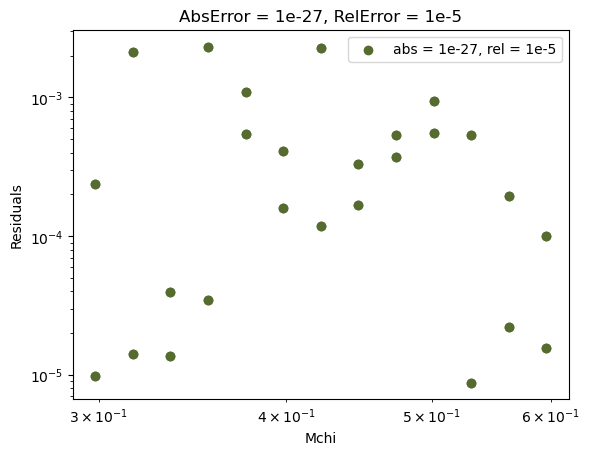

In [50]:
import matplotlib.pyplot as plt
#plt.scatter(m_list, sigma_py_list, color = 'fuchsia', label = 'Python Sigma Analytic')
#plt.scatter(m_list, sigma_math_list, color = 'black', label = 'Mathematica Sigma Analytic')
plt.scatter(m_list, residuals_list, color = 'darkolivegreen', label = 'abs = 1e-27, rel = 1e-5')
plt.xscale('log'); plt.yscale('log')
plt.title("AbsError = 1e-27, RelError = 1e-5")
plt.xlabel('Mchi'); #plt.ylabel('Sigma Analytic')
plt.ylabel("Residuals")
plt.legend()

Text(0, 0.5, 'Cubic Residual')

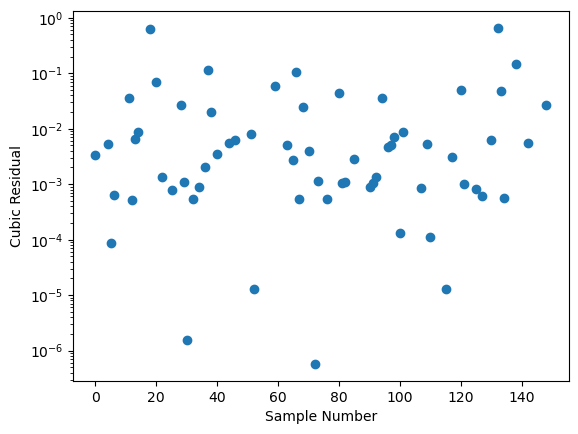

In [59]:
import matplotlib.pyplot as plt
plt.scatter(countlist, residual_list)
#plt.xscale('log'); 
plt.yscale('log')
#plt.title(f"Eps = {eps_val:.3e}")
plt.xlabel('Sample Number'); plt.ylabel('Cubic Residual')

In [26]:
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.differentiate import derivative

In [27]:
#from scipy.integrate import solve_ivp

'''def getsoln(gchi, mchi, eps):
    x_span = (0.1, 200)
    x_eval = np.linspace(0.1, 200, 1000)
    y0 = [np.log(y_eq(gchi, mchi, mchi / x_span[0]))]

    sol = solve_ivp(lambda x, y: soln(y, x, gchi, mchi, eps),
                    x_span, y0, method='Radau',
                    t_eval=x_eval, rtol=1e-8, atol=1e-10)
    return sol'''

def soln(y, x, gchi, mchi, eps):
    T = mchi / x
    
    s_val = s_value(T, mchi)
    ds_dT_val = ds_dT(T, mchi)
    #if math.log10(mchi) > -0.53 and math.log10(mchi) < -0.2:
    #    sigmav = sigmaAnalytic(x, eps, mchi, 1e-27, 1e-5)
    sigmav_log10_x3 = interp_log10_x3([x, eps, mchi])[0]
    sigmav = 10**sigmav_log10_x3
    
    
    # Use interpolated cross section like the Mathematica code does
    #sigmav = 10**interp([T, eps, mchi])[0]
    #sigmav = interp([T, eps, mchi])[0]
    
    #sigmav_log10 = interp_log10([T, eps, mchi])[0]
    #sigmav = 10**sigmav_log10
    #sigmav = sigmaAnalytic(x, eps, mchi)
    
    #sigmav = 10**(interp([mchi, eps, T])[0])
    
    num1 = (s_val * sigmav) / (hubble(T, mchi) * x)
    num2 = (((1.0 / 3.0) * (T * ds_dT_val)) / s_val)
    #num3 = (y_eq(gchi, mchi, T)**2) * np.exp(-y) - np.exp(y)
    log_yeq = np.log(y_eq(gchi, mchi, T))
    log_term1 = 2 * log_yeq - y

    log_term2 = y

    if log_term1 > log_term2:
        num3 = np.exp(log_term1) * (1.0 - np.exp(log_term2 - log_term1))
    else:
        num3 = -np.exp(log_term2) * (1.0 - np.exp(log_term1 - log_term2))
    #if num3 > 1e8:
        #print("num1 =", num1, "num2 = ", num2, "num3 = ", num3)
        #print("total = ", f"{num1*num2*num3:.3e}
    #num3 = (y_eq(gchi, mchi, T)**2) * np.exp(-y) - np.exp(y)
    
    return num1 * num2 * num3

In [28]:
def soln_ln(y, x, gchi, mchi, eps):
    u = math.log(x)
    T = mchi*np.exp(-u)
    
    s_val = s_value(T, mchi)
    ds_dT_val = ds_dT(T, mchi)
    
    # Use interpolated cross section like the Mathematica code does
    #sigmav = 10**interp([T, eps, mchi])[0]
    #sigmav = interp([T, eps, mchi])[0]
    
    #sigmav_log10 = interp_log10([T, eps, mchi])[0]
    #sigmav = 10**sigmav_log10
    '''if mchi < 1e-2:
        sigmav = sigmaAnalytic(T, eps, mchi)
        
    else: 
        sigmav_log10 = interp_log10([T, eps, mchi])[0]
        sigmav = 10**sigmav_log10'''

    sigmav_log10_x = interp_log10_x([x, eps, mchi])[0]
    sigmav = 10**sigmav_log10_x
    
    
    
    if sigmav < 0:
        print("ERROR")
        print(sigmav_log10)
    #sigmav = sigmaAnalytic(T, eps, mchi)
    
    #sigmav = 10**(interp([mchi, eps, T])[0])
    
    num1 = (s_val * sigmav) / (hubble(T, mchi))
    num2 = (((1.0 / 3.0) * (T * ds_dT_val)) / s_val)
    #num3 = (y_eq(gchi, mchi, T)**2) * np.exp(-y) - np.exp(y)
    '''log_yeq = np.log(y_eq(gchi, mchi, T))
    log_term1 = 2 * log_yeq - y
    log_term2 = y

    if log_term1 > log_term2:
        num3 = np.exp(log_term1) * (1.0 - np.exp(log_term2 - log_term1))
    else:
        num3 = -np.exp(log_term2) * (1.0 - np.exp(log_term1 - log_term2))'''
    
    return num1 * num2 * num3

In [29]:
'''def getsoln(gchi, mchi, eps):
    #x = np.logspace(-1, 1.7, 100)
    x = np.linspace(0.1, 200, 1000)
    y0 = np.log(y_eq(gchi, mchi, (mchi / x[0])))
    sol = odeint(soln, y0, x, args=(gchi, mchi, eps))
    return sol'''
'''def getsoln(gchi, mchi, eps, x_start, x_end, ode_method, rto, ato):
    x_span = (x_start, x_end)
    #print("x span=", x_span)
    
    #x_span_log = (math.log10(x_start), math.log10(x_end))
    x_eval_log = np.logspace(math.log10(x_start), math.log10(x_end), 100)
    #print("x eval log=", x_eval_log)
    

    y0 = [np.log(y_eq(gchi, mchi, mchi / x_span[0]))]
    
    x_eval_log = np.clip(x_eval_log, x_span[0], x_span[1])
    #changing t_eval = x_eval_log to t_eval = None for speed
    sol = solve_ivp(lambda x, y: soln(y, x, gchi, mchi, eps),
                    x_span, y0, method=ode_method,
                    t_eval=x_eval_log, rtol=rto, atol=ato)
    return sol'''

def getsoln(gchi, mchi, eps, x_start, x_end, ode_method, rto, ato):
    x_span = (x_start, x_end)
    x_eval_log = np.logspace(math.log10(x_start), math.log10(x_end), 100)
    x_eval_log = np.clip(x_eval_log, x_span[0], x_span[1])
    y0 = [np.log(y_eq(gchi, mchi, mchi / x_span[0]))]

    
    sol = solve_ivp(lambda x, y: soln(y, x, gchi, mchi, eps),
                    x_span, y0, method=ode_method,
                    t_eval=x_eval_log, rtol=rto, atol=ato)

    # Retry with Radau and tighter tolerances if failed
    if not sol.success:
        print("trying again")
        print("mchi: ", mchi, "eps: ", eps)
        sol = solve_ivp(lambda x, y: soln(y, x, gchi, mchi, eps),
                        x_span, y0, method="Radau",
                        t_eval=x_eval_log, rtol=1e-4, atol=1e-6)

    # Last resort: try with dense output and looser tolerances
    if not sol.success:
        print("trying again again")
        sol = solve_ivp(lambda x, y: soln(y, x, gchi, mchi, eps),
                        x_span, y0, method="Radau",
                        t_eval=x_eval_log, rtol=1e-6, atol=1e-8)

    if not sol.success:
        print(f"Warning — all methods failed: mchi={mchi:.3e}, eps={eps:.3e}: {sol.message}")

    return sol

5.900000000000001e-05


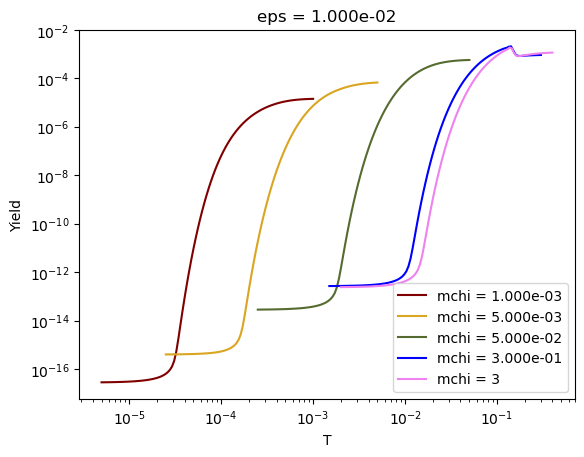

In [31]:
#testm = .001;
#test = soln[2, testm, 10^-2]
import matplotlib.pyplot as plt
testm = [0.001, 0.005, 0.05, 3e-1, 4e-1]
testing_m = 0.001
eps_testing = 1e-2

'''#test = getsoln(2, testm, 1e-2, 0.1, 50)
start1 = time.time()
baseline_testbdf = getsoln(2, testm, 1e-2, 0.1, 50, "BDF", 1e-8, 1e-10)
print('time baseline test bdf', time.time()-start1)'''
time1 = time.time()
testsoly1 = getsoln(1, testm[0], eps_testing, 1, 200, "Radau", 1e-3, 1e-5)
#print(time.time() - time1)
testsoly2 = getsoln(1, testm[1], eps_testing, 1, 200, "Radau", 1e-3, 1e-5)
testsoly3 = getsoln(1, testm[2], eps_testing, 1, 200, "Radau", 1e-3, 1e-5)
testsoly4 = getsoln(1, testm[3], eps_testing, 1, 200, "Radau", 1e-3, 1e-5)
testsoly5 = getsoln(1, testm[4], eps_testing, 1, 200, "Radau", 1e-3, 1e-5)

#y1 = math.exp(testsoly1.y[0])
#print(testsoly1)

x1 = testsoly1.t
x2 = testsoly2.t
x3 = testsoly3.t
x4 = testsoly4.t
x5 = testsoly5.t
'''
sigma_vals = [sigmaAnalytic(x, eps_testing, testing_m) for x in x1]
interp_vals_cub = [10**interp_log10_x3([x, eps_testing, testing_m])[0] for x in x1]
sigma_array = np.asarray(sigma_vals)
interp_array = np.asarray(interp_vals_cub)
residuals = (sigma_array - interp_array)/sigma_array
residuals = np.absolute(residuals)

y_eq_vals = [y_eq(2, testing_m, testing_m/i) for i in x1]
#x5 = testm[4]/testsoly5.t'''
'''
x1 = testsoly1.t
x2 = testsoly2.t
x3 = testsoly3.t
x4 = testsoly4.t
x5 = testsoly5.t'''
#print(y_eq_vals[-1])
#plt.plot(x1, residuals, color = 'orange')
#plt.plot(x1, interp_vals_cub, color = 'violet', label = "Interperlation")
#print(np.exp(testsoly1.y)[0])
plt.plot(testm[0]/x1, testm[0]*np.exp(testsoly1.y)[0], color = "maroon", label = f"mchi = {testm[0]:.3e}")
#plt.plot(x1, y_eq_vals, color = "violet", label = "Ye2 for each x")
plt.plot(testm[1]/x2, testm[1]*np.exp(testsoly2.y)[0], color = "goldenrod", label = f"mchi = {testm[1]:.3e}")
plt.plot(testm[2]/x3, testm[2]*np.exp(testsoly3.y)[0], color = "darkolivegreen", label = f"mchi = {testm[2]:.3e}")
plt.plot(testm[3]/x4, testm[3]*np.exp(testsoly4.y)[0], color = "b", label = f"mchi = {testm[3]:.3e}")
plt.plot(testm[4]/x5, testm[4]*np.exp(testsoly5.y)[0], color = "violet", label = "mchi = 3")

plt.xscale('log')
plt.yscale('log')
plt.xlabel('T'); plt.ylabel('Yield')
plt.title(f"eps = {eps_testing:.3e}")

plt.legend()
plt.show()

In [62]:
import matplotlib.pyplot as plt
'''T_guess = 0.2
mchi_guess = 0.02
eps_guess = 0.7

print(interp([mchi_test[11], eps_test[27], T_test[0]]))
print(interp([T_test[0], eps_test[27], mchi_test[11]]))
print(sigmaAnalytic(T_test[0], eps_test[27], mchi_test[11]))'''
mchi = 2.268e-02
x_start = 0.1
T_start = mchi / x_start
print(f"T at x_start: {T_start:.3e} GeV")
print(f"Is this within your interpolator range?")
print(f"sigmav at T_start: {interp([T_start, 1.585e-05, mchi])[0]:.3e}")
print(f"gStar at T_start:  {interp_spline_gStar(mchi, T_start)}")

T at x_start: 2.268e-01 GeV
Is this within your interpolator range?
sigmav at T_start: -4.022e-07
gStar at T_start:  [[57.78132566]]


In [63]:
# Check sigmav sign across the failing points
failing_points = [
    (2.268e-02, 1.585e-05),
    (4.948e-02, 1.585e-05),
    (2.268e-02, 4.299e-04),
    (4.948e-02, 4.299e-04),
    (2.268e-02, 1.166e-02),
    (4.948e-02, 1.166e-02),
    (2.182e-03, 3.162e-01),
    (4.762e-03, 3.162e-01),
]

for mchi, eps in failing_points:
    T_start = mchi / 0.1  # x_start = 0.1
    sv = interp([T_start, eps, mchi])[0]
    print(f"mchi={mchi:.3e}, eps={eps:.3e}, T={T_start:.3e}: sigmav={sv:.3e} {'❌ NEGATIVE' if sv < 0 else '✓'}")

mchi=2.268e-02, eps=1.585e-05, T=2.268e-01: sigmav=-4.022e-07 ❌ NEGATIVE
mchi=4.948e-02, eps=1.585e-05, T=4.948e-01: sigmav=9.829e-07 ✓
mchi=2.268e-02, eps=4.299e-04, T=2.268e-01: sigmav=-2.956e-04 ❌ NEGATIVE
mchi=4.948e-02, eps=4.299e-04, T=4.948e-01: sigmav=7.224e-04 ✓
mchi=2.268e-02, eps=1.166e-02, T=2.268e-01: sigmav=-2.180e-01 ❌ NEGATIVE
mchi=4.948e-02, eps=1.166e-02, T=4.948e-01: sigmav=5.328e-01 ✓
mchi=2.182e-03, eps=3.162e-01, T=2.182e-02: sigmav=-4.324e+01 ❌ NEGATIVE
mchi=4.762e-03, eps=3.162e-01, T=4.762e-02: sigmav=-3.924e+02 ❌ NEGATIVE


raw interp output: -4.022e-07
if log10: 10^sv = 1.000e+00


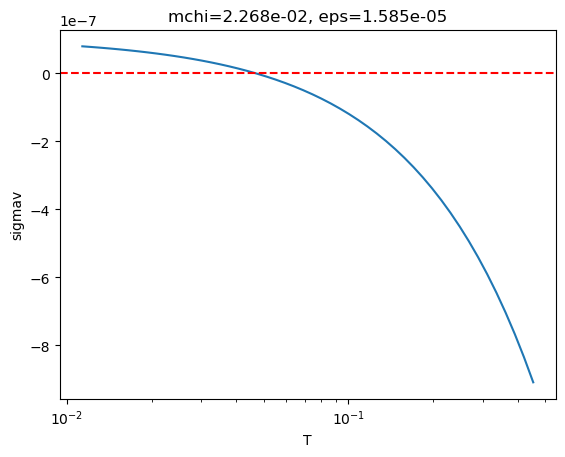

In [64]:
# Check if interp returns log10(sigmav) instead of sigmav
mchi, eps = 2.268e-02, 1.585e-05
T = mchi / 0.1
sv = interp([T, eps, mchi])[0]
print(f"raw interp output: {sv:.3e}")
print(f"if log10: 10^sv = {10**sv:.3e}")

# Also scan sigmav vs T for this mchi/eps to see where it goes negative
T_range = np.logspace(np.log10(mchi*0.5), np.log10(mchi*20), 50)
sv_range = [interp([T, eps, mchi])[0] for T in T_range]
plt.plot(T_range, sv_range)
plt.axhline(0, color='r', linestyle='--')
plt.xscale('log')
plt.xlabel('T'); plt.ylabel('sigmav')
plt.title(f'mchi={mchi:.3e}, eps={eps:.3e}')
plt.show()

In [72]:
#print(np.exp(test.t))
#print(x, np.exp(test.y))
#print(test)
#print(test_200.t)
#print(test_200.y[0][-1])
#print(interp([0.1, 0.05, 0.1]))
#print(sigmaAnalytic(0.1, 0.05, 0.1))

# Check x values at x_start for failing points
failing_mchi = [2.268e-02, 4.948e-02, 2.182e-03, 4.762e-03]
for mchi in failing_mchi:
    T_start = mchi / 0.1
    x_at_start = mchi / T_start
    print(f"mchi={mchi:.3e}, T_start={T_start:.3e}, x={x_at_start:.3e} (interpolator x_min=0.1)")

# Verify sigmav is positive at new x_start for previously failing points
failing_mchi = [2.268e-02, 4.948e-02, 2.182e-03, 4.762e-03]
for mchi in failing_mchi:
    T_start = mchi / 0.5
    sv = interp([T_start, 1.585e-05, mchi])[0]
    print(f"mchi={mchi:.3e}, T_start={T_start:.3e}, sigmav={sv:.3e} {'✓' if sv > 0 else '❌ NEGATIVE'}")


#NEW
print("NEW")
# Check that Y ≈ Y_eq at x_start = 0.5 for a few points
for mchi in [1e-3, 1e-2, 1e-1, 1.0]:
    T = mchi / 0.5
    yeq = y_eq(1, mchi, T)
    print(f"mchi={mchi:.3e}, T={T:.3e}, Y_eq={yeq:.3e}")

mchi=2.268e-02, T_start=2.268e-01, x=1.000e-01 (interpolator x_min=0.1)
mchi=4.948e-02, T_start=4.948e-01, x=1.000e-01 (interpolator x_min=0.1)
mchi=2.182e-03, T_start=2.182e-02, x=1.000e-01 (interpolator x_min=0.1)
mchi=4.762e-03, T_start=4.762e-02, x=1.000e-01 (interpolator x_min=0.1)
mchi=2.268e-02, T_start=4.536e-02, sigmav=3.121e-09 ✓
mchi=4.948e-02, T_start=9.896e-02, sigmav=1.865e-07 ✓
mchi=2.182e-03, T_start=4.364e-03, sigmav=5.208e-07 ✓
mchi=4.762e-03, T_start=9.524e-03, sigmav=1.094e-07 ✓
NEW
mchi=1.000e-03, T=2.000e-03, Y_eq=1.453e-02
mchi=1.000e-02, T=2.000e-02, Y_eq=1.407e-02
mchi=1.000e-01, T=2.000e-01, Y_eq=3.999e-03
mchi=1.000e+00, T=2.000e+00, Y_eq=2.630e-03


Text(0, 0.5, 'Residual')

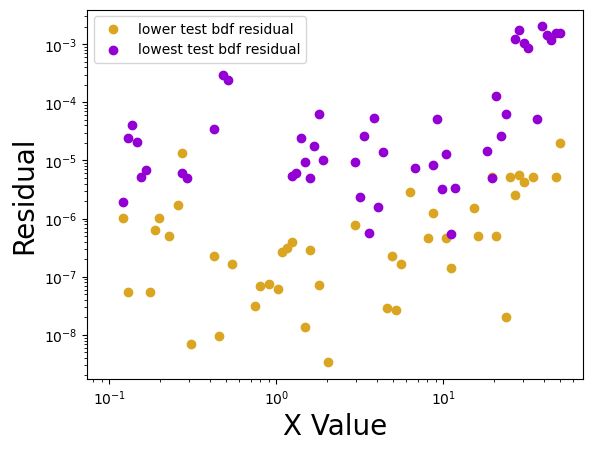

In [109]:
#print(test)
import matplotlib.pyplot as plt
import math
from matplotlib import colormaps
import matplotlib.colors as colors
import matplotlib.cm as cmx
testm = 0.001
ax = plt.gca()
x = np.logspace(math.log10(0.1), math.log10(50), 100)

#x = np.logspace(-1, 1.7, 100)
#x = np.linspace(0.5, 50, 1000)
T_values = testm/x
y_values = y_eq_np(2, testm, T_values)
#plt.scatter(np.exp(test), y_values, c="k")
#plt.scatter(test, y_values, c = "k")
#plt.scatter(x, np.exp(baseline_testbdf.y), c = 'maroon', label = "baseline test bdf")
plt.scatter(x, (np.exp(bdflower_test.y) - np.exp(baseline_testbdf.y))/np.exp(baseline_testbdf.y), c = 'goldenrod', label = "lower test bdf residual")
plt.scatter(x, (np.exp(bdflowest_test.y) - np.exp(baseline_testbdf.y))/np.exp(baseline_testbdf.y), c = 'darkviolet', label = "lowest test bdf residual")
#plt.scatter(x, np.exp(baseline_testradau.y), c = 'aqua', label = "baseline test radau")
#plt.scatter(x, np.exp(radaulower_test.y), c = 'limegreen', label = "lower test radau")
#plt.scatter(x, np.exp(radaulowest_test.y), c = 'gold', label = "lowest test radau")
#plt.scatter(x, y_values, c = 'b')
#plt.plot(np.exp(test), y_values, c = "b")
plt.xscale('log')
plt.yscale('log')
plt.legend()
#plt.ylim( (10**-14,10**-12) )
#plt.xlim(10**1, 10**2)
ax.set_xlabel("X Value", fontsize = 20)
ax.set_ylabel("Residual", fontsize = 20)

In [35]:
'''test_test_list = []
counter = 0
test_array = np.ones((5,3))
test_check_array = np.ones((5,3))
print(test_array[0,0])
j_values = np.linspace(4,8, 5)
i_values = np.linspace(7,9,3)
for j in range(len(j_values)):
    for i in range(len(i_values)):
            int_value = test_func(i_values[i], j_values[j])
            #print(int_value)
            #print(i, j, k)
            test_array[int(j)] = int_value
            test_test_list.append(int_value)
#print(test_array)
for j in range(len(j_values)):
    for i in range(len(i_values)):
            test_check_array[int(j), int(i)] = test_test_list[counter]
            counter += 1
print(test_check_array)'''

#plt.scatter(x, np.exp(bdflowest_test.y), c = 'darkviolet', label = "lowest test bdf")
#bdflowest_test = getsoln(2, testm, 1e-2, 0.1, 50, "BDF", 1e-4, 1e-6)

from multiprocessing.pool import Pool
values_list_full = []
values_list_one = []

mx_values_ode = np.logspace(-3.1, 0.06, 10)
eps_values_ode_full = np.logspace(-5.9, -1, 4)
eps_values_ode_one = np.logspace(-5.3, -0.5, 4)

ode_full_array = np.ones((len(mx_values_ode), len(eps_values_ode_full)))
ode_one_array = np.ones((len(mx_values_ode), len(eps_values_ode_one)))
ode_full_array_m = np.ones((len(mx_values_ode), len(eps_values_ode_full)))
ode_one_array_m = np.ones((len(mx_values_ode), len(eps_values_ode_one)))

ode_full_list = []
ode_one_list = []
#ode_full_list_m = []
#ode_one_list_m = []

counter_full = 0
counter_one = 0
start_3 = time.time()
for j in range(len(eps_values_ode_full)):
    for i in range(len(mx_values_ode)):
        #print(i,j)
        values_list_full.append((1, mx_values_ode[i], eps_values_ode_full[j], 1, 200, "Radau", 1e-3, 1e-5))
        values_list_one.append((1, mx_values_ode[i], eps_values_ode_one[j], 1, 200, "Radau", 1e-3, 1e-5))
        #test_full = getsoln(1, mx_values_ode[i], eps_values_ode_full[j], 1, 200)
        #test_full_val = test_full.y[0][-1]
        #test_one = getsoln(1, mx_values_ode[i], eps_values_ode_one[j], 1, 200)
        #test_one_val = test_one.y[0][-1]
        #ode_full_list.append(math.exp(test_full_val))
        #ode_one_list.append(math.exp(test_one_val))
        
if __name__ == "__main__":
    with Pool() as pool:
        result_data_full = pool.starmap(getsoln, values_list_full, chunksize = 5)
        result_data_one = pool.starmap(getsoln, values_list_one, chunksize = 5)
        #result_data_full = result_data_full.y[0][-1]
        #result_data_one = result_data_one.y[0][-1]
print(time.time() - start_3)

ode_full_list = [math.exp(sol.y[0][-1]) for sol in result_data_full]
ode_one_list  = [math.exp(sol.y[0][-1]) for sol in result_data_one]


for j in range(len(eps_values_ode_full)):
    for i in range(len(mx_values_ode)):
        ode_full_array[int(i), int(j)] = ode_full_list[counter_full]
        ode_full_array_m[int(i), int(j)] = mx_values_ode[i]*ode_full_list[counter_full]
        counter_full += 1
        ode_one_array[int(i), int(j)] = ode_one_list[counter_one]
        ode_one_array_m[int(i), int(j)] = mx_values_ode[i]*ode_one_list[counter_one]
        counter_one += 1


/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_33696/679938310.py:42: RuntimeWarning: overflow encountered in exp
  num3 = np.exp(log_term1) * (1.0 - np.exp(log_term2 - log_term1))
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_33696/679938310.py:44: RuntimeWarning: overflow encountered in exp
  num3 = -np.exp(log_term2) * (1.0 - np.exp(log_term1 - log_term2))
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_33696/679938310.py:42: RuntimeWarning: overflow encountered in exp
  num3 = np.exp(log_term1) * (1.0 - np.exp(log_term2 - log_term1))
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_33696/679938310.py:44: RuntimeWarning: overflow encountered in exp
  num3 = -np.exp(log_term2) * (1.0 - np.exp(log_term1 - log_term2))
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_33696/679938310.py:42: RuntimeWarning: overflow encountered in exp
  num3 = np.exp(log_term1) * (1.0 - np.exp(log_term2 - log_term1))
/var/folders/9q/3gw00nr55_19xv6gq

4.418856143951416


/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_23403/3909196078.py:48: RuntimeWarning: overflow encountered in exp
  num3 = (y_eq(gchi, mchi, T)**2) * np.exp(-y) - np.exp(y)


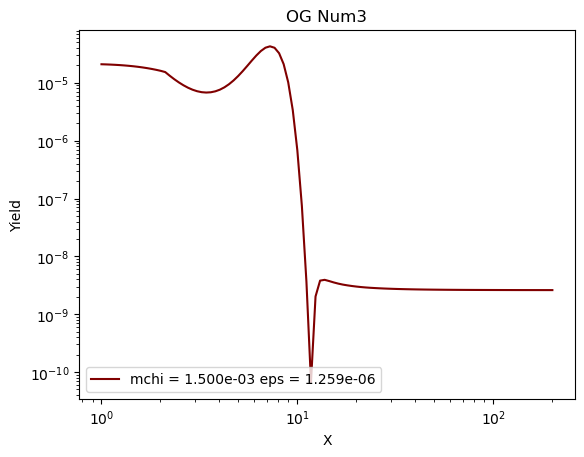

In [121]:
mchi_test = 0.0015
eps_test = 1.2589e-6
testsolyinf = getsoln(1, mchi_test, eps_test, 1, 200, "Radau", 1e-3, 1e-5)
plt.plot(testsolyinf.t, mchi_test*np.exp(testsolyinf.y)[0], color = "maroon", label = f"mchi = {mchi_test:.3e} eps = {eps_test:.3e}")

plt.xscale('log')
plt.yscale('log')
plt.xlabel('X'); plt.ylabel('Yield')
plt.title("OG Num3")

plt.legend()
plt.show()

In [123]:
failed_one = sum(1 for sol in result_data_one if not sol.success)
failed_full = sum(1 for sol in result_data_full if not sol.success)
print(f"Failed full: {failed_full}/{len(result_data_full)}")
print(f"Failed one:  {failed_one}/{len(result_data_one)}")

Failed full: 0/4000
Failed one:  0/4000


In [124]:
print(f"min Y*m: {ode_one_array_m.min():.3e}")
print(f"max Y*m: {ode_one_array_m.max():.3e}")
print(f"target in range? {ode_one_array_m.min() < 2.16e-10 < ode_one_array_m.max()}")

min Y*m: 3.404e-19
max Y*m: 9.783e-06
target in range? True


In [77]:
np.save("FullAbundanceTab.npy", ode_full_array)
np.save("OneAbundanceTab.npy", ode_one_array)
np.save("FullAbundanceTabM.npy", ode_full_array_m)
np.save("OneAbundanceTabM.npy", ode_one_array_m)
'''ode_full_array_m = np.ones((len(mx_values_ode), len(eps_values_ode_full)))
ode_one_array_m = np.ones((len(mx_values_ode), len(eps_values_ode_one)))
counter_full = 0
counter_one = 0
for j in range(len(eps_values_ode_full)):
    for i in range(len(mx_values_ode)):
        ode_full_array_m[int(i), int(j)] = mx_values_ode[i]*ode_full_list[counter_full]
        counter_full += 1
        ode_one_array_m[int(i), int(j)] = mx_values_ode[i]*ode_one_list[counter_one]
        counter_one += 1'''
'''for j in range(4):
    for i in range(5,10):
        sol = getsoln(1, mx_values_ode[i], eps_values_ode_full[j], 0.1, 200, "BDF", 1e-6, 1e-8)
        sol_exp = math.exp(sol.y[0][-1])
        print(ode_one_array_m[i][j])
        #print(sol_exp*mx_values_ode[i]  == ode_full_array_m[i][j])
        #print(sol_exp*mx_values_ode[i]  == interp_one_m((mx_values_ode[i], eps_values_ode_one[j])))
        #print(interp_one((mx_values_ode[i], eps_values_ode_one[j])))'''
'''failed_points_one = []
for idx, sol in enumerate(result_data_one):
    if not sol.success:
        j = idx // len(mx_values_ode)
        i = idx % len(mx_values_ode)
        failed_points_one.append((i, j, mx_values_ode[i], eps_values_ode_one[j], sol.message))
        print(f"mchi={mx_values_ode[i]:.3e}, eps={eps_values_ode_one[j]:.3e}: {sol.message}")

print(f"\nTotal failed: {len(failed_points_one)}/{len(result_data_one)}")'''

'failed_points_one = []\nfor idx, sol in enumerate(result_data_one):\n    if not sol.success:\n        j = idx // len(mx_values_ode)\n        i = idx % len(mx_values_ode)\n        failed_points_one.append((i, j, mx_values_ode[i], eps_values_ode_one[j], sol.message))\n        print(f"mchi={mx_values_ode[i]:.3e}, eps={eps_values_ode_one[j]:.3e}: {sol.message}")\n\nprint(f"\nTotal failed: {len(failed_points_one)}/{len(result_data_one)}")'

In [61]:
np.save("FullAbundanceTab.npy", ode_full_array)
np.save("OneAbundanceTab.npy", ode_one_array)
np.save("FullAbundanceTabM.npy", ode_full_array_m)
np.save("OneAbundanceTabM.npy", ode_one_array_m)

In [127]:
'''from scipy.interpolate import RegularGridInterpolator
import numpy as np
def f(x, y, z):
    return 2 * x**3 + 3 * y**2 - z
x = np.linspace(1, 4, 11)
y = np.linspace(4, 7, 22)
z = np.linspace(7, 9, 33)
xg, yg ,zg = np.meshgrid(x, y, z, indexing='ij', sparse=True)
data = f(xg, yg, zg)
print(data.shape)'''
mx_values_ode = np.logspace(-3.1, 0.06, 100)
eps_values_ode_full = np.logspace(-5.9, -1, 40)
eps_values_ode_one = np.logspace(-5.3, -0.5, 40)
from scipy.interpolate import RegularGridInterpolator
#np.save("FullAbundanceTab.npy", ode_full_array)
#np.save("OneAbundanceTab.npy", ode_one_array)
#np.save("FullAbundanceTabM.npy", ode_full_array_m)
#np.save("OneAbundanceTabM.npy", ode_one_array_m)
#ode_full_array = np.load("FullAbundanceTab.npy")
#ode_one_array = np.load("OneAbundanceTab.npy")
#ode_full_array_m = np.load("FullAbundanceTabM.npy")
#ode_one_array_m = np.load("OneAbundanceTabM.npy")
#interp_full = RegularGridInterpolator((mx_values_ode, eps_values_ode_full), ode_full_array, bounds_error=False, fill_value=None)
#interp_one = RegularGridInterpolator((mx_values_ode, eps_values_ode_one), ode_one_array, bounds_error=False, fill_value=None)
interp_full_m = RegularGridInterpolator((mx_values_ode, eps_values_ode_full), np.log10(ode_full_array_m), method='cubic', bounds_error=False, fill_value=None)
interp_one_m = RegularGridInterpolator((mx_values_ode, eps_values_ode_one), np.log10(ode_one_array_m), method='cubic', bounds_error=False, fill_value=None)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(m_vals, eps_Full_vals, color = "goldenrod")
plt.plot(m_vals, eps_One_vals, color = "maroon")

plt.xscale('log')
plt.yscale('log')
plt.xlabel('M_chi')
plt.ylabel('Eps')
plt.legend()
plt.show()

In [57]:
mx_values_ode = np.logspace(-3.1, 0.06, 100)
eps_test_list = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
target = (4.32e-10)/2
m_eps_combo = np.ones((100, 5))
for i in range(len(mx_values_ode)):
    m_eps_combo[i, 0] = mx_values_ode[i]
    for j in range(len(eps_test_list)):
        if j < (len(eps_test_list) - 1):
            
            test_low = getsoln(1, mx_values_ode[i], eps_test_list[j], 1, 200, "Radau", 1e-3, 1e-5)
            y_eps_low_calc = mx_values_ode[i]* np.exp(test_low.y)[0][-1]
            test_high = getsoln(1, mx_values_ode[i], eps_test_list[j+1], 1, 200, "Radau", 1e-3, 1e-5)
            y_eps_high_calc = mx_values_ode[i]* np.exp(test_high.y)[0][-1]

            sign_low = np.sign(y_eps_low_calc - target)
            sign_high = np.sign(y_eps_high_calc - target)

            if sign_low != sign_high:
                m_eps_combo[i, 1] = eps_test_list[j]
                m_eps_combo[i, 3] = eps_test_list[j+1]
                m_eps_combo[i, 2] = y_eps_low_calc
                m_eps_combo[i, 4] = y_eps_high_calc
                break
        else:
            break
print(m_eps_combo)

/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_87961/2439191.py:46: RuntimeWarning: overflow encountered in exp
  num3 = -np.exp(log_term2) * (1.0 - np.exp(log_term1 - log_term2))
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_87961/2439191.py:44: RuntimeWarning: overflow encountered in exp
  num3 = np.exp(log_term1) * (1.0 - np.exp(log_term2 - log_term1))
/opt/anaconda3/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2768: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_87961/2439191.py:52: RuntimeWarning: overflow encountered in multiply
  return num1 * num2 * num3


KeyboardInterrupt: 

In [35]:
np.save("relicmepslist.npy", m_eps_combo)

In [32]:
mx_values_ode = np.logspace(-3.1, 0.06, 100)
eps_test_list = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
target = (4.32e-10)/2

In [33]:
m_eps_array = np.load("relicmepslist.npy")
print(len(m_eps_array))

100


In [34]:
from scipy import optimize
m_eps_array = np.load("relicmepslist.npy")
target = (4.32e-10)/2
eps_full_tab = np.ones((len(m_eps_array), 2))

def root_function_full(eps, mchi):
    print(eps, mchi)
    test = getsoln(1, mchi, eps, 1, 200, "Radau", 1e-3, 1e-5)
    y_calc = mchi* np.exp(test.y)[0][-1]

    diff = y_calc - target
    return diff

for i in range(len(mx_values_ode)):
    root_full = optimize.brentq(root_function_full, m_eps_array[i,1], m_eps_array[i, 3], xtol = math.pow(10, -8), args = (m_eps_array[i,0]))
    eps_full_tab[i][0] = m_eps_array[i, 0]
    eps_full_tab[i][1] = root_full



1e-06 0.0007943282347242813
1e-05 0.0007943282347242813
9.36310641973172e-06 0.0007943282347242813
5.1815532098658604e-06 0.0007943282347242813
3.09077660493293e-06 0.0007943282347242813
4.2105517201703495e-06 0.0007943282347242813
3.772043108004101e-06 0.0007943282347242813
3.841192481850154e-06 0.0007943282347242813
3.83131452747517e-06 0.0007943282347242813
1e-06 0.000854907627575011
1e-05 0.000854907627575011
9.439671085473157e-06 0.000854907627575011
5.219835542736579e-06 0.000854907627575011
3.1099177713682893e-06 0.000854907627575011
4.457850612839806e-06 0.000854907627575011
4.0105850868826055e-06 0.000854907627575011
4.079316377854445e-06 0.000854907627575011
4.069909859940647e-06 0.000854907627575011
1e-06 0.0009201071040105031
1e-05 0.0009201071040105031
9.508696341670152e-06 0.0009201071040105031
5.254348170835076e-06 0.0009201071040105031
3.127174085417538e-06 0.0009201071040105031
4.688927367133761e-06 0.0009201071040105031
4.275715852603576e-06 0.0009201071040105031
4.33

ValueError: f(a) and f(b) must have different signs

In [45]:
print(eps_full_tab)

[[7.94328235e-04 4.50665685e-06]
 [8.54907628e-04 4.82665362e-06]
 [9.20107104e-04 5.17748040e-06]
 [9.90279014e-04 5.55704188e-06]
 [1.06580258e-03 5.95223169e-06]
 [1.14708595e-03 6.36277834e-06]
 [1.23456839e-03 6.79550416e-06]
 [1.32872267e-03 7.23736944e-06]
 [1.43005762e-03 7.70486284e-06]
 [1.53912087e-03 8.18020408e-06]
 [1.65650183e-03 8.67874392e-06]
 [1.78283483e-03 9.19908858e-06]
 [1.91880262e-03 9.75328227e-06]
 [2.06513998e-03 1.03360431e-05]
 [2.22263775e-03 1.09682633e-05]
 [2.39214708e-03 1.16465033e-05]
 [2.57458403e-03 1.23804087e-05]
 [2.77093452e-03 1.31833144e-05]
 [2.98225966e-03 1.40504758e-05]
 [3.20970151e-03 1.50129343e-05]
 [3.45448919e-03 1.60563000e-05]
 [3.71794559e-03 1.71981830e-05]
 [4.00149448e-03 1.84378614e-05]
 [4.30666821e-03 1.97979584e-05]
 [4.63511599e-03 2.12827482e-05]
 [4.98861281e-03 2.28914053e-05]
 [5.36906906e-03 2.46487992e-05]
 [5.77854077e-03 2.65567368e-05]
 [6.21924082e-03 2.86311320e-05]
 [6.69355083e-03 3.08800322e-05]
 [7.204034

In [46]:
np.save("epsfulltab.npy", eps_full_tab)

In [35]:
eps_full_tab = np.load("epsfulltab.npy")
print(eps_full_tab)

[[7.94328235e-04 4.50505919e-06]
 [8.54907628e-04 4.82843171e-06]
 [9.20107104e-04 5.18134994e-06]
 [9.90279014e-04 5.55260593e-06]
 [1.06580258e-03 5.95021304e-06]
 [1.14708595e-03 6.36080826e-06]
 [1.23456839e-03 6.79270727e-06]
 [1.32872267e-03 7.24057962e-06]
 [1.43005762e-03 7.70017858e-06]
 [1.53912087e-03 8.18163979e-06]
 [1.65650183e-03 8.67480121e-06]
 [1.78283483e-03 9.20134958e-06]
 [1.91880262e-03 9.74760415e-06]
 [2.06513998e-03 1.03397895e-05]
 [2.22263775e-03 1.09686214e-05]
 [2.39214708e-03 1.16412683e-05]
 [2.57458403e-03 1.23808152e-05]
 [2.77093452e-03 1.31756738e-05]
 [2.98225966e-03 1.40564623e-05]
 [3.20970151e-03 1.50061264e-05]
 [3.45448919e-03 1.60571407e-05]
 [3.71794559e-03 1.71940630e-05]
 [4.00149448e-03 1.84395011e-05]
 [4.30666821e-03 1.97979096e-05]
 [4.63511599e-03 2.12797944e-05]
 [4.98861281e-03 2.28944786e-05]
 [5.36906906e-03 2.46457337e-05]
 [5.77854077e-03 2.65363373e-05]
 [6.21924082e-03 2.86325351e-05]
 [6.69355083e-03 3.08791176e-05]
 [7.204034

/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_96466/3157449803.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


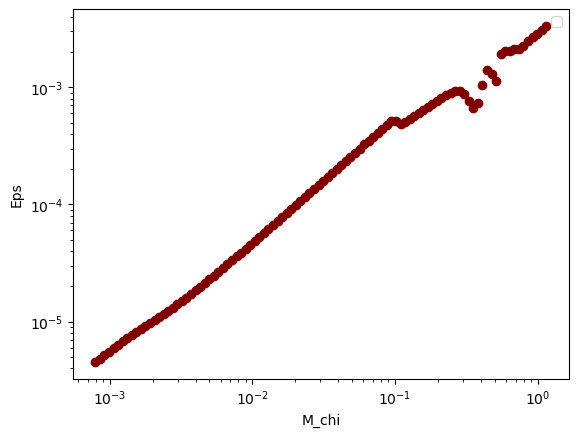

In [37]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(eps_full_tab[:, 0], eps_full_tab[:, 1], color = "maroon")
#plt.plot(m_vals, 0.01*sigmaOne_vals, label ="sigma Bare 1%", color = "maroon")

#plt.plot(m_vals, eps_Full_vals, color = "goldenrod",label =  "Eps Full")
#plt.plot(m_vals, eps_One_vals, color = "maroon", label = "Eps One Percent")

plt.xscale('log')
plt.yscale('log')
#plt.ylim(1e-15, 1e-7)
plt.xlabel('M_chi')
plt.ylabel('Eps')
plt.legend()
plt.show()

In [38]:
from scipy import optimize
count_bad_values_full = 0
count_bad_values_one = 0
eps_full_tab = np.ones((len(mx_values_ode), 2))
eps_one_tab = np.ones((len(mx_values_ode), 2))
#YFullAbundance = np.ones((len(mx_values_ode), len(mx_values_ode)))
#YOneAbundance = np.ones((len(mx_values_ode), len(eps_values_ode_one)))
target = (4.32e-10)/2

def root_function_full(ep, mx):
    #print(mx, type(mx))
    #print(ep, type(ep))
    
    interp_value = interp_full_m((mx, ep))
    diff = 10**interp_value - target
    return diff
def root_function_one(ep, mx):
    interp_value_one = interp_one_m((mx, ep))
    diff_one = 10**interp_value_one - target
    return diff_one
for i in range(len(mx_values_ode)):
    #root_full = optimize.brentq(root_function_full, a = eps_values_ode_full[0], b = eps_values_ode_full[-1], xtol = math.pow(10, -4), args = (mx_values_ode[i]))
    #root_one = optimize.brentq(root_function_one, a = eps_values_ode_one[0], b = eps_values_ode_one[-1], xtol = math.pow(10, -2.5), args = (mx_values_ode[i]))
    #eps_full_tab[i][0] = mx_values_ode[i]
    #eps_full_tab[i][1] = root_full
    #eps_one_tab[i][0] = mx_values_ode[i]
    #eps_one_tab[i][1] = root_one
    if np.sign(root_function_full(eps_values_ode_full[0], mx_values_ode[i])) == np.sign(root_function_full(eps_values_ode_full[-1], mx_values_ode[i])):
        print("ERROR", math.log10(mx_values_ode[i]))
        count_bad_values_full += 1
        eps_full_tab[i][0] = mx_values_ode[i]
        eps_full_tab[i][1] = math.nan
    else:
        root_full = optimize.brentq(root_function_full, a = eps_values_ode_full[0], b = eps_values_ode_full[-1], xtol = math.pow(10, -4), args = (mx_values_ode[i]))
        eps_full_tab[i][0] = mx_values_ode[i]
        eps_full_tab[i][1] = root_full
    if np.sign(root_function_one(eps_values_ode_one[0], mx_values_ode[i])) == np.sign(root_function_one(eps_values_ode_one[-1], mx_values_ode[i])):
        print("ERROR", math.log10(mx_values_ode[i]))
        count_bad_values_one += 1
        eps_one_tab[i][0] = mx_values_ode[i]
        eps_one_tab[i][1] = math.nan
    else:
        ###
        #print("success")
        #root_full = optimize.brentq(root_function_full, a = eps_values_ode_full[0], b = eps_values_ode_full[-1], xtol = math.pow(10, -4), args = (mx_values_ode[i]))
        root_one = optimize.brentq(root_function_one, a = eps_values_ode_one[0], b = eps_values_ode_one[-1], xtol = math.pow(10, -2.5), args = (mx_values_ode[i]))
        #eps_full_tab[i][0] = mx_values_ode[i]
        #eps_full_tab[i][1] = root_full
        eps_one_tab[i][0] = mx_values_ode[i]
        eps_one_tab[i][1] = root_one

NameError: name 'eps_values_ode_full' is not defined

In [39]:
import sympy as sp
import warnings

# --- Define all unit symbols ---
(GeV, sec, cm, km, m, AU, Mpc, kpc, pb, pc, K, eV, TeV, keV, MeV,
 gm, kg, ton, Watt, Joule, year, Gauss, Tesla, Coulomb,
 MSolar, Msolar, Msun, GN, Mpl, Mplred) = sp.symbols(
    'GeV sec cm km m AU Mpc kpc pb pc K eV TeV keV MeV gm kg ton '
    'Watt Joule year Gauss Tesla Coulomb MSolar Msolar Msun GN Mpl Mplred'
)

# --- Conversion rules (equivalent of the Mathematica `NaturalUnits` list) ---
NATURAL_UNITS = {
    sec: 3e10 * cm,
    km: 1e5 * cm,
    m: 1e2 * cm,
    AU: 14959787070000 * cm,
    cm: 5.0676e13 * GeV**-1,
    Mpc: 30.857e23 * cm,
    kpc: 30.857e20 * cm,
    pb: 1e-36 * cm**2,
    pc: 1e-3 * kpc,
    K: 0.0000861772 * eV,
    eV: 1e-9 * GeV,
    TeV: 1e3 * GeV,
    keV: 1e-6 * GeV,
    MeV: 1e-3 * GeV,
    gm: 5.62e23 * GeV,
    kg: 1e3 * gm,
    ton: 1e3 * kg,
    Watt: Joule / sec,
    Joule: 6.242e18 * eV,
    year: 3.154e7 * sec,
    Gauss: 1e-4 * Tesla,
    Tesla: kg / (Coulomb * sec),
    Coulomb: 1.89e18,
    MSolar: Msun,
    Msolar: Msun,
    Msun: 1.989e30 * kg,
    GN: 1 / Mpl**2,
    Mpl: 1.22e19 * GeV,
    Mplred: Mpl / sp.sqrt(8 * sp.pi),
}


def _replace_repeated(expr, rules, max_iter=50):
    """Equivalent of Mathematica's `expr //. rules` (ReplaceRepeated)."""
    current = sp.sympify(expr)
    for _ in range(max_iter):
        new = current.subs(rules)
        if new == current:
            break
        current = new
    return current


def _units_part(expr):
    """
    Extract the 'dimension' part of an expression that has been fully
    reduced to (numeric coefficient) * GeV**n. Mirrors the Mathematica
    code's use of `inGeV[[-1]]` / `outGeV[[1]]` to pull out the GeV power.
    """
    expr = sp.sympify(expr)
    if expr.is_number:
        return sp.Integer(1)
    _, gev_part = expr.as_independent(GeV, as_Add=False)
    return gev_part


def convert_natural_units(in_expr, out_expr, rules=NATURAL_UNITS):
    """
    Convert `in_expr` into the units represented by `out_expr`.

    Example:
        convert_natural_units(1*eV, K)   -> numeric_value * K
        convert_natural_units(1*Mpc, cm) -> numeric_value * cm
    """
    in_expr = sp.sympify(in_expr)
    out_expr = sp.sympify(out_expr)

    in_GeV = _replace_repeated(in_expr, rules)
    out_GeV = _replace_repeated(out_expr, rules)

    in_units = _units_part(in_GeV)
    out_units = _units_part(out_GeV)

    if in_units == out_units:
        return sp.nsimplify(in_GeV / out_GeV) * out_expr
    else:
        warnings.warn(
            f"ConvertNaturalUnits::incompatible: The units of {in_expr} and "
            f"{out_expr} are not compatible. Converting {in_expr} to natural "
            f"units [GeV]."
        )
        return in_GeV


# --- Example usage ---
if __name__ == "__main__":
    print(convert_natural_units(1 * eV, K))      # 1 eV in Kelvin
    print(convert_natural_units(1 * Mpc, cm))    # 1 Mpc in cm
    print(convert_natural_units(1 * GeV, gm))    # 1 GeV in grams
    print(convert_natural_units(1 * cm, GeV))    # incompatible-looking case (still works: length -> GeV^-1)
    print(convert_natural_units(1 * cm, sec))    # length -> time, compatible (both GeV^-1)
    print(convert_natural_units(1 * GeV, sec))   # energy vs time -> triggers the incompatibility warning

58019986725027*K/5000000000
3085700000000000000000000*cm
88967971530249*gm/50000000000000000000000000000000000000
50676000000000.0/GeV
333333333333333*sec/10000000000000000000000000
GeV


/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_96466/1713682067.py:90: UserWarning: ConvertNaturalUnits::incompatible: The units of cm and GeV are not compatible. Converting cm to natural units [GeV].
  warnings.warn(
/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_96466/1713682067.py:90: UserWarning: ConvertNaturalUnits::incompatible: The units of GeV and sec are not compatible. Converting GeV to natural units [GeV].
  warnings.warn(


In [40]:
convFac = float(convert_natural_units(1. / GeV**2, cm**2) / cm**2)
print(convFac)

3.89399460115405e-28


In [36]:
eps_vals = eps_full_tab[:, 1]
masses_vals = eps_full_tab[:, 0]
print(masses_vals)

[7.94328235e-04 8.54907628e-04 9.20107104e-04 9.90279014e-04
 1.06580258e-03 1.14708595e-03 1.23456839e-03 1.32872267e-03
 1.43005762e-03 1.53912087e-03 1.65650183e-03 1.78283483e-03
 1.91880262e-03 2.06513998e-03 2.22263775e-03 2.39214708e-03
 2.57458403e-03 2.77093452e-03 2.98225966e-03 3.20970151e-03
 3.45448919e-03 3.71794559e-03 4.00149448e-03 4.30666821e-03
 4.63511599e-03 4.98861281e-03 5.36906906e-03 5.77854077e-03
 6.21924082e-03 6.69355083e-03 7.20403406e-03 7.75344927e-03
 8.34476559e-03 8.98117861e-03 9.66612763e-03 1.04033142e-02
 1.11967224e-02 1.20506397e-02 1.29696810e-02 1.39588129e-02
 1.50233808e-02 1.61691380e-02 1.74022763e-02 1.87294598e-02
 2.01578609e-02 2.16951989e-02 2.33497819e-02 2.51305515e-02
 2.70471315e-02 2.91098793e-02 3.13299424e-02 3.37193184e-02
 3.62909201e-02 3.90586449e-02 4.20374500e-02 4.52434335e-02
 4.86939211e-02 5.24075599e-02 5.64044192e-02 6.07060986e-02
 6.53358454e-02 7.03186796e-02 7.56815292e-02 8.14533763e-02
 8.76654129e-02 9.435121

In [37]:
#print(eps_one_tab)
'''def gStarInt(m):
    gStarInt = scipy.interpolate.interp1d(gdata[:,0], gdata[:,2],bounds_error=False,fill_value="extrapolate")
    return gStarInt(m)'''

def epsFullInt(m):
    epsFullInt = scipy.interpolate.interp1d(masses_vals, eps_vals,bounds_error=False,kind = 'cubic', fill_value="extrapolate")
    return epsFullInt(m)

def epsOneInt(m):
    epsOneInt = scipy.interpolate.interp1d(eps_one_tab_complete[:,0], eps_one_tab_complete[:,1],bounds_error=False,fill_value="extrapolate")
    return epsOneInt(m)

In [42]:
for r in epsFullTab_np:
    dif = abs(r[1] - epsFullInt(r[0]))
    residual = dif/r[1]
    #print(residual)

NameError: name 'epsFullTab_np' is not defined

In [60]:
def sigmaBareFull_math(i):
    mx = epsFullTab_np[i][0]
    epsFullInt = epsFullTab_np[i][1]
    mu_val = (mx*0.511e-3)/(mx + 0.511e-3)
    num1 = (epsFullInt * math.sqrt(4*math.pi*0.5)) ** 2
    num2 = 16*math.pi*mu_val*mu_val * (1/137)
    square_val = (3*mx)**2 + (1/137)**2 + (0.511e-3)**2
    denom = 4*math.pi*math.pow(square_val, 2)
    ans = (num1*num2)/denom
    answer_converted = ans*convFac
    return answer_converted

In [38]:
def sigmaBareFull_scatter(mx, eps, gx):
    mu_val = (mx*0.511e-3)/(mx + 0.511e-3)
    alpha = 1/137
    mA = 3*mx
    num = 4*alpha*gx*gx*eps*eps*mu_val*mu_val
    denom = mA*mA*mA*mA
    ans = num /denom
    answer_converted = ans
    return answer_converted

In [65]:
def sigmaBareFull(mx):
    mu_val = (mx*0.511e-3)/(mx + 0.511e-3)
    num1 = (epsFullInt(mx) * math.sqrt(4*math.pi*0.5)) ** 2
    num2 = 16*math.pi*mu_val*mu_val * (1/137)
    square_val = (3*mx)**2 + ((1/137)**2 )*((0.511e-3)**2)
    denom = 4*math.pi*math.pow(square_val, 2)
    ans = (num1*num2)/denom
    answer_converted = ans*convFac
    answer_converted = ans
    return answer_converted

In [41]:
print(epsFullInt(0.75))
print(epsFullInt(1e-3))
print(epsFullInt(1e-2))
print(epsFullInt(1e-1))
print(sigmaBareFull_scatter(1e-3, 5.604023127846173e-06, 1))
print(sigmaBareFull_scatter(1e-2, 4.695388080217386e-05, 1))
print(sigmaBareFull_scatter(1e-1, 0.000518023751166445, 1))

0.0021396590678457285
5.604023127846173e-06
4.695388080217386e-05
0.000518023751166445
1.294693938698415e-09
1.878240148525901e-11
2.500163223929614e-13


In [45]:
def sigmaBareOne(mx):
    mu_val = (mx*0.511e-3)/(mx + 0.511e-3)
    num1 = (epsOneInt(mx) * math.sqrt(4*math.pi*0.5)) ** 2
    num2 = 16*math.pi*mu_val*mu_val * (1/137)
    square_val = (3*mx)**2 + (1/137)**2 + (0.511e-3)**2
    denom = 4*math.pi*math.pow(square_val, 2)
    ans = (num1*num2)/denom
    return ans

In [46]:
sigmaBareFull_np = np.frompyfunc(sigmaBareFull, 1, 1)
#sigmaBareOne_np = np.frompyfunc(sigmaBareOne, 1, 1)

In [61]:
import pandas as pd
mathematica_sigmabare = pd.read_csv('/Users/afurataylor/Downloads/relic_abundance_calc 4/sigmaBareFullScalar.csv')
epsFullTab = pd.read_csv('/Users/afurataylor/Downloads/relic_abundance_calc 4/epsFullScalarTab.csv')
epsFullTab_np = epsFullTab.to_numpy()
mathematica_sigmabare_np = mathematica_sigmabare.to_numpy()
print(mathematica_sigmabare_np[0])
print(epsFullTab_np[0])
#x, y = data[:, 0], data[:, 1]

[1.25892541e-03 2.11198615e-36]
[1.25892541e-03 6.74784677e-06]


In [48]:
#print(mathematica_sigmabare)

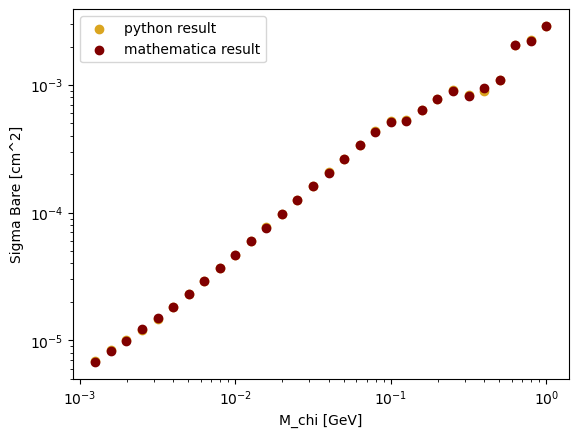

In [62]:
import matplotlib.pyplot as plt

m_mathematica_list = []
sigmabare_mathematica_list = []
eps_mathematica_list = []
sigma_mathematica_list_test = []

for r in epsFullTab_np:
    eps_mathematica_list.append(r[1])
    
for r in mathematica_sigmabare_np:
    m_mathematica_list.append(r[0])
    sigmabare_mathematica_list.append(r[1])

m_python_list = [e for e in m_mathematica_list]
#print(m_mathematica_list)
m_vals = eps_full_tab[:, 0]

#for i in range(len(epsFullTab_np)):
#    sigma_mathematica_list_test.append(sigmaBareFull_math(i))

#sigmaFull_vals = sigmaBareFull_np(m_python_list)
#sigmaOne_vals = sigmaBareOne_np(m_vals)

eps_Full_vals = [epsFullInt(i) for i in m_python_list]
#eps_One_vals = [epsOneInt(j) for j in m_vals]

m_mathematica_list = []
sigmabare_mathematica_list = []
#for r in mathematica_sigmabare_np:
#    m_mathematica_list.append(r[0])
#    sigmabare_mathematica_list.append(r[1])

#sigmaFull_python = np.array(sigmaFull_vals)
#sigmaFull_math = np.array(sigmabare_mathematica_list)
#residual_sigma = (sigmaFull_python - sigmaFull_math)/sigmaFull_math

eps_python = np.array(eps_Full_vals)
eps_math = np.array(eps_mathematica_list)
residual_eps = abs((eps_python - eps_math)/eps_math)

plt.figure()
#plt.plot(m_python_list, sigmaFull_vals, label = "sigma Bare Full python", color = "goldenrod")
#plt.plot(m_python_list, sigmabare_mathematica_list, label = 'sigma Bare Full mathematica', color = 'maroon')
#plt.plot(m_python_list, sigma_mathematica_list_test, label = 'sigma Bare Full mathematica test', color = 'black')
#plt.plot(m_python_list, abs(residual_sigma), label = "residual", color = "fuchsia")
#plt.plot(m_vals, 0.01*sigmaOne_vals, label ="sigma Bare 1%", color = "maroon")
#plt.plot(mathematica_sigmabare[:, 0], mathematica_sigmabare[:, 1], label = "mathematica", color = "maroon")
#plt.plot(m_vals, eps_Full_vals, color = "goldenrod",label =  "Eps Full")
#plt.plot(m_vals, eps_One_vals, color = "maroon", label = "Eps One Percent")

plt.scatter(m_python_list, eps_Full_vals, label = "python result", color = "goldenrod")
plt.scatter(m_python_list, eps_mathematica_list, label = 'mathematica result', color = 'maroon')
#plt.plot(m_python_list, residual_eps, color = "fuchsia")

plt.xscale('log')
plt.yscale('log')
#plt.ylim(1e-15, 1e-7)
#plt.xlim(1e-3, 1e-2)
plt.xlabel('M_chi [GeV]')
plt.ylabel('Sigma Bare [cm^2]')
#plt.ylabel('Residual Sigma')
#plt.ylabel('Residual Eps')
plt.legend()
plt.show()

/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_13226/4203667051.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  answer = math.sqrt((8*math.pi/(3*m_planck*m_planck))*rho_value)


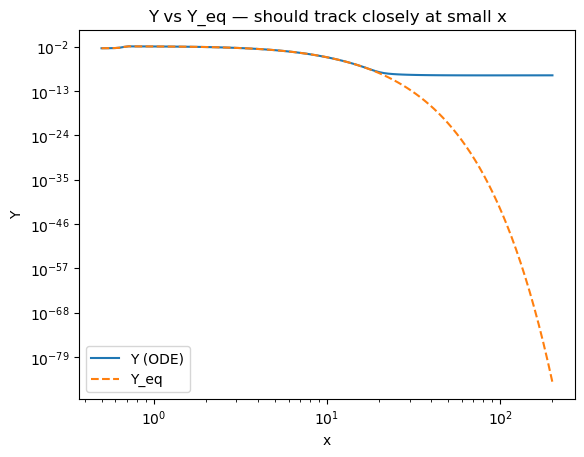

Y at x_start:    3.999e-03
Y_eq at x_start: 3.999e-03
Ratio Y/Y_eq:    1.000  # should be ~1.0


In [73]:
# Check that Y tracks Y_eq closely at early times (x ~ 0.5 to 5)
gchi, mchi, eps = 1, 0.1, 1e-3
sol = getsoln(gchi, mchi, eps, 0.5, 200, "BDF", 1e-6, 1e-8)

x_vals = sol.t
yeq_vals = [y_eq(gchi, mchi, mchi/x) for x in x_vals]

plt.figure()
plt.plot(x_vals, np.exp(sol.y[0]), label='Y (ODE)')
plt.plot(x_vals, yeq_vals, label='Y_eq', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('x')
plt.ylabel('Y')
plt.legend()
plt.title('Y vs Y_eq — should track closely at small x')
plt.show()

print(f"Y at x_start:    {np.exp(sol.y[0][0]):.3e}")
print(f"Y_eq at x_start: {yeq_vals[0]:.3e}")
print(f"Ratio Y/Y_eq:    {np.exp(sol.y[0][0])/yeq_vals[0]:.3f}  # should be ~1.0")

Failed full: 7/40
Failed one:  8/40


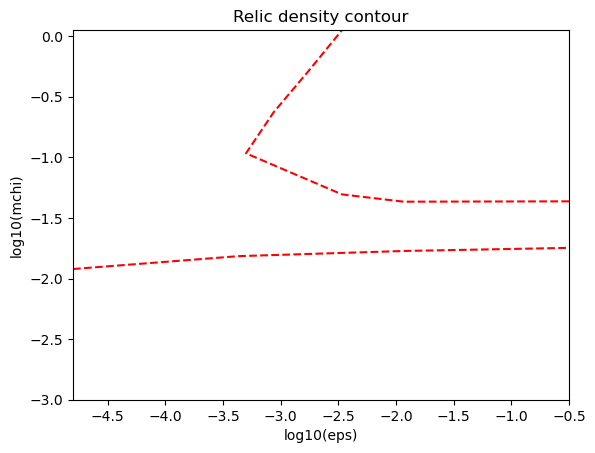

min Y*m: 5.649e-21
max Y*m: 2.850e-04
target in range? True


In [74]:
# After rerunning with x_start = 0.5
failed_one = sum(1 for sol in result_data_one if not sol.success)
failed_full = sum(1 for sol in result_data_full if not sol.success)
print(f"Failed full: {failed_full}/{len(result_data_full)}")
print(f"Failed one:  {failed_one}/{len(result_data_one)}")

# And check the contour
plt.figure()
cont = plt.contour(np.log10(eps_values_ode_one),
                   np.log10(mx_values_ode),
                   np.log10(ode_one_array_m),
                   levels=[np.log10(2.16e-10)],
                   colors='red')
plt.xlabel('log10(eps)')
plt.ylabel('log10(mchi)')
plt.title('Relic density contour')
plt.show()

print(f"min Y*m: {ode_one_array_m.min():.3e}")
print(f"max Y*m: {ode_one_array_m.max():.3e}")
print(f"target in range? {ode_one_array_m.min() < 2.16e-10 < ode_one_array_m.max()}")

In [32]:
test_check_array = np.ones((len(x),len(y),len(z)))
counter = 0
test_test_list = []
for k in range(len(z)):
    for j in range(len(y)):
        for i in range(len(x)):
            int_value = f(x[i], y[j], z[k])
            test_test_list.append(int_value)

for k in range(len(z)):
    for j in range(len(y)):
        for i in range(len(x)):
            test_check_array[int(i), int(j), int(k)] = test_test_list[counter]
            counter += 1
#print(test_check_array)
#print(test_check_array.shape)

In [33]:
#print(data == test_check_array)

/var/folders/9q/3gw00nr55_19xv6gqvyhh3z80000gn/T/ipykernel_21421/349653691.py:28: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(T_test, final_array[i, :, mchi_num], c=colorVal, label = "Mchi = " + labelmchi + " , T = " + labelt )


[]

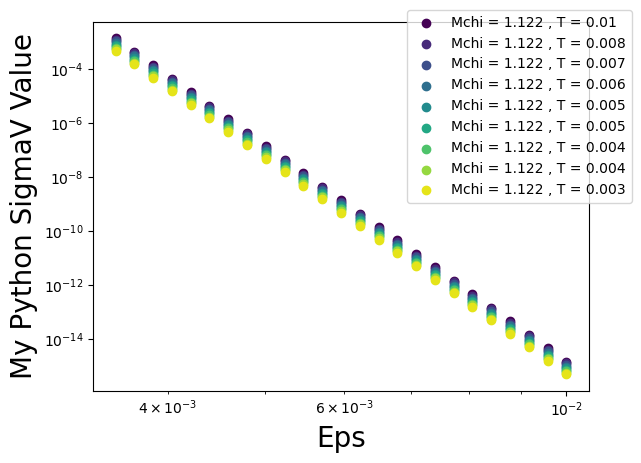

In [148]:
import matplotlib.pyplot as plt
import math
from matplotlib import colormaps
import matplotlib.colors as colors
import matplotlib.cm as cmx

viridis = cm = plt.get_cmap('viridis') 
cNorm  = colors.Normalize(vmin=0, vmax=len(eps_test))
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=viridis)

def truncate(number, digits) -> float:
    # Improve accuracy with floating point operations, to avoid truncate(16.4, 2) = 16.39 or truncate(-1.13, 2) = -1.12
    nbDecimals = len(str(number).split('.')[1]) 
    if nbDecimals <= digits:
        return number
    stepper = 10.0 ** digits
    return math.trunc(stepper * number) / stepper

ax = plt.gca()
i = 0
mchi_num = 24
while i < len(mchi_test):
    t_value = T_test[i]
    labelt = str(truncate(t_value, 3))
    mchi_value = mchi_test[mchi_num]
    labelmchi = str(truncate(mchi_value, 3))
    colorVal = scalarMap.to_rgba(i)
    plt.scatter(T_test, final_array[i, :, mchi_num], c=colorVal, label = "Mchi = " + labelmchi + " , T = " + labelt )
    i = i + 3
plt.xscale('log')
plt.yscale('log')
#plt.plot(m_values, gStarSIntvalues, c='darkgoldenrod', ls = '--', label = "gStar S Values")
ax.legend(bbox_to_anchor=(1.1, 1.05))
ax.set_xlabel("Eps", fontsize = 20)
ax.set_ylabel("My Python SigmaV Value", fontsize = 20)
plt.plot()

In [151]:
x = np.linspace(1, 3, 3)
y = np.linspace(4, 7, 4)
z = np.linspace(8, 12, 5)

In [152]:
def f(x, y, z):
    return x- y*z
xg, yg ,zg = np.meshgrid(x, y, z, indexing='ij', sparse=True)
data = f(xg, yg, zg)
print(data)
print(data.shape)

[[[-31. -35. -39. -43. -47.]
  [-39. -44. -49. -54. -59.]
  [-47. -53. -59. -65. -71.]
  [-55. -62. -69. -76. -83.]]

 [[-30. -34. -38. -42. -46.]
  [-38. -43. -48. -53. -58.]
  [-46. -52. -58. -64. -70.]
  [-54. -61. -68. -75. -82.]]

 [[-29. -33. -37. -41. -45.]
  [-37. -42. -47. -52. -57.]
  [-45. -51. -57. -63. -69.]
  [-53. -60. -67. -74. -81.]]]
(3, 4, 5)


In [38]:
print(test_func(test1, test2, test3))

[[[14. 15. 16. 17. 18. 19. 20.]
  [15. 16. 17. 18. 19. 20. 21.]
  [16. 17. 18. 19. 20. 21. 22.]]

 [[15. 16. 17. 18. 19. 20. 21.]
  [16. 17. 18. 19. 20. 21. 22.]
  [17. 18. 19. 20. 21. 22. 23.]]

 [[16. 17. 18. 19. 20. 21. 22.]
  [17. 18. 19. 20. 21. 22. 23.]
  [18. 19. 20. 21. 22. 23. 24.]]

 [[17. 18. 19. 20. 21. 22. 23.]
  [18. 19. 20. 21. 22. 23. 24.]
  [19. 20. 21. 22. 23. 24. 25.]]

 [[18. 19. 20. 21. 22. 23. 24.]
  [19. 20. 21. 22. 23. 24. 25.]
  [20. 21. 22. 23. 24. 25. 26.]]]


In [153]:
test_test_list = []
counter = 0
test_array = np.ones((3,4,5))
test_check_array = np.ones((3,4,5))
print(test_array[0,0,0])
k_values = np.linspace(9, 15, 7)
j_values = np.linspace(4,8, 5)
i_values = np.linspace(1,3,3)
for k in range(len(z)):
    for j in range(len(y)):
        for i in range(len(x)):
            int_value = f(x[i], y[j], z[k])
            #print(int_value)
            #print(i, j, k)
            test_array[int(i), int(j), int(k)] = int_value
            test_test_list.append(int_value)
#print(test_array)
for k in range(len(z)):
    for j in range(len(y)):
        for i in range(len(x)):
            test_check_array[int(i), int(j), int(k)] = test_test_list[counter]
            counter += 1
print(test_check_array)
print(test_check_array.shape)
print(test_check_array == data)

1.0
[[[-31. -35. -39. -43. -47.]
  [-39. -44. -49. -54. -59.]
  [-47. -53. -59. -65. -71.]
  [-55. -62. -69. -76. -83.]]

 [[-30. -34. -38. -42. -46.]
  [-38. -43. -48. -53. -58.]
  [-46. -52. -58. -64. -70.]
  [-54. -61. -68. -75. -82.]]

 [[-29. -33. -37. -41. -45.]
  [-37. -42. -47. -52. -57.]
  [-45. -51. -57. -63. -69.]
  [-53. -60. -67. -74. -81.]]]
(3, 4, 5)
[[[ True  True  True  True  True]
  [ True  True  True  True  True]
  [ True  True  True  True  True]
  [ True  True  True  True  True]]

 [[ True  True  True  True  True]
  [ True  True  True  True  True]
  [ True  True  True  True  True]
  [ True  True  True  True  True]]

 [[ True  True  True  True  True]
  [ True  True  True  True  True]
  [ True  True  True  True  True]
  [ True  True  True  True  True]]]


In [154]:
test1, test2=np.meshgrid(np.linspace(7,9,3), np.linspace(4,8, 5))
example = test_func(test1, test2)
print(example.shape)
print(test_func(test1, test2))

NameError: name 'test_func' is not defined

In [100]:
test_test_list = []
counter = 0
test_array = np.ones((5,3))
test_check_array = np.ones((5,3))
print(test_array[0,0])
j_values = np.linspace(4,8, 5)
i_values = np.linspace(7,9,3)
for j in range(len(j_values)):
    for i in range(len(i_values)):
            int_value = test_func(i_values[i], j_values[j])
            #print(int_value)
            #print(i, j, k)
            test_array[int(j)] = int_value
            test_test_list.append(int_value)
#print(test_array)
for j in range(len(j_values)):
    for i in range(len(i_values)):
            test_check_array[int(j), int(i)] = test_test_list[counter]
            counter += 1
print(test_check_array)

1.0
[[11. 12. 13.]
 [12. 13. 14.]
 [13. 14. 15.]
 [14. 15. 16.]
 [15. 16. 17.]]
